In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
from itertools import combinations
import cmocean as cmc
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

plt.style.use('../plotstyling.mplstyle')

In [2]:
db_filename = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
ds = xr.open_dataset(db_filename)

In [8]:
np.where(ds.Latitude.values > 60)[0].shape

(2054823,)

In [3]:
Fwp       = ds.Fwp.values
Fwc       = ds.Fwc.values
Lwc       = ds.Lwc.values
Zm        = ds.Fwp_Zm.values / 1000          # km
Dm        = ds.Fwp_Dm.values / 1e-6          # microm
Latitude  = ds.Latitude.values
Longitude = ds.Longitude.values
Surf_z    = ds.Surf_Z.values
altitude  = ds.vertical_level.values / 1000  # km

channels = [
    "AWS21", 
    "AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", 
    "AWS44", "AWS43", "AWS42", "AWS41"
]
channels_diffs = [
    "21-31", 
    "31-32", "32-33", "33-34", "34-35", "35-36", 
    "36-44", "44-43", "43-42", "42-41"
]
ch_to_idx = {ch: i for i, ch in enumerate(channels)}

Ta_array = np.zeros((Latitude.shape[0], len(channels)))
CS_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array[:, i] = ds[f"Ta_Allsky_{ch}"].values
    CS_array[:, i] = ds[f"Ta_Clearsky_{ch}"].values - ds[f"Ta_Allsky_{ch}"].values

def Ta(ch):
    return ds[f"Ta_Allsky_AWS{ch}"].values

Fwp_bins = np.logspace(-2, 2, 100)
Fwc_bins = np.logspace(-3, 2, 100)
Zm_bins  = np.linspace(0, 20, 100)
Dm_bins  = np.linspace(0, 1000, 101)
Dm_bins_mm  = np.linspace(0, 2, 101)
Ta_bins  = np.linspace(80, 300, 111)
dTb_bins = np.linspace(-20, 80, 21)
altitude_bins = np.linspace(0,20,21)
Ta_bins_wider = np.linspace(80, 300, 56)

In [4]:
Ta_bins_wider

array([ 80.,  84.,  88.,  92.,  96., 100., 104., 108., 112., 116., 120.,
       124., 128., 132., 136., 140., 144., 148., 152., 156., 160., 164.,
       168., 172., 176., 180., 184., 188., 192., 196., 200., 204., 208.,
       212., 216., 220., 224., 228., 232., 236., 240., 244., 248., 252.,
       256., 260., 264., 268., 272., 276., 280., 284., 288., 292., 296.,
       300.])

In [5]:
altitude[24]

np.float64(6.0)

In [6]:
case = "amazon"

case_configs = {
    "congo_basin": {
        "Fwp": 1, "surface_altitude": 1000, "Zm": 6,
        "lat": (-10, 10), "lon": (-5, 40),
        "Fwc_threshold": 3e-4, "Fwc_levels": (24, 48),
    },
    "amazon": {
        "Fwp": 1, "surface_altitude": 500, "Zm": 6,
        "lat": (-15, 10), "lon": (-80, -40),
        "Fwc_threshold": 3e-4, "Fwc_levels": (24, 48),
    },
    "US_plains": {
        "Fwp": 1, "surface_altitude": 1000, "Zm": 6,
        "lat": (30, 50), "lon": (-110, -80),
        "Fwc_threshold": 1e-4, "Fwc_levels": (24, 56),
    },
    "maritime_continent": {
        "Fwp": 1, "surface_altitude": 100, "Zm": 6,
        "lat": (-10, 15), "lon": (90, 130),
        "Fwc_threshold": 3e-4, "Fwc_levels": (24, 48),
    },
    "congo_amazon": {
        "Fwp": 1, "surface_altitude": 500, "Zm": 6,
        "lat": (-15, 10),
        "lon_regions": [(-5, 40), (-80, -40)],
        "Fwc_threshold": 1e-4, "Fwc_levels": (24, 56),
    },
}

filter_info = case_configs[case]
lat_min, lat_max = filter_info["lat"]
fwc_thresh     = filter_info["Fwc_threshold"]
fwc_lo, fwc_hi = filter_info["Fwc_levels"]

# Handle single or multiple longitude regions
if "lon_regions" in filter_info:
    lon_mask = np.zeros(Latitude.shape[0], dtype=bool)
    for lon_min, lon_max in filter_info["lon_regions"]:
        lon_mask |= (Longitude > lon_min) & (Longitude < lon_max)
else:
    lon_min, lon_max = filter_info["lon"]
    lon_mask = (Longitude > lon_min) & (Longitude < lon_max)

region_mask = (Latitude > lat_min) & (Latitude < lat_max) & lon_mask

dc_mask = (
    region_mask &
    (Fwp    > filter_info["Fwp"]) &
    (Zm     > filter_info["Zm"]) &
    (Surf_z < filter_info["surface_altitude"]) &
    (np.all(Fwc[:, fwc_lo:fwc_hi] > fwc_thresh, axis=1))
)
no_dc_mask = (
    region_mask &
    (Fwp > 1e-2) &
    ~dc_mask
)

filter_idxs       = np.where(dc_mask)[0]
filter_idxs_no_dc = np.where(no_dc_mask)[0]
filter_idxs_region   = np.where(region_mask)[0]

print(f"Case:           {case}")
print(f"DC cases:       {len(filter_idxs)}")
print(f"Non-DC cases:   {len(filter_idxs_no_dc)}")
print(f"All region:     {len(filter_idxs_region)}")

Case:           amazon
DC cases:       509
Non-DC cases:   29863
All region:     129669


/tmp/ipykernel_9362/1118800851.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


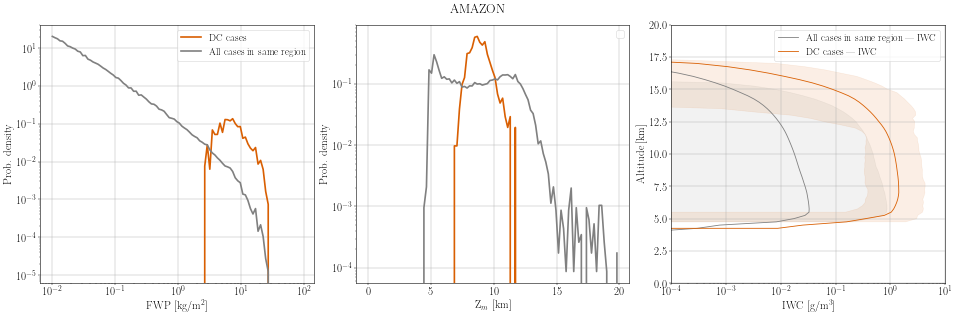

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

counts, _ = np.histogram(Fwp[dc_mask], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="C1", label="DC cases")
counts, _ = np.histogram(Fwp[region_mask], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="grey", label="All cases in same region")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("FWP [kg/m$^{2}$]")
axes[0].set_ylabel("Prob. density")

counts, _ = np.histogram(Zm[dc_mask], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="C1")
counts, _ = np.histogram(Zm[region_mask], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="grey")
axes[1].set_yscale("log")
axes[1].set_xlabel("Z$_{m}$ [km]")
axes[1].set_ylabel("Prob. density")

# IWC and LWC profiles
for mask, color, label in [
    (region_mask, "grey", "All cases in same region"),
    (dc_mask,     "C1",   "DC cases"),
]:
    for hydrometeor, arr, ls in [
        ("IWC", Fwc*1000, "-"),
        #("LWC", Lwc*1000, "--"),
    ]:
        profiles     = arr[mask, :]
        mean_profile = np.mean(profiles, axis=0)
        p01_profile  = np.percentile(profiles,  1, axis=0)
        p99_profile  = np.percentile(profiles, 99, axis=0)

        axes[2].plot(mean_profile, altitude, c=color, lw=1.5, ls=ls,
                     label=f"{label} — {hydrometeor}")
        axes[2].fill_betweenx(altitude, p01_profile, p99_profile,
                              color=color, alpha=0.1)

axes[2].set_xscale("log")
axes[2].set_xlabel("IWC [g/m$^{3}$]")
axes[2].set_ylabel("Altitude [km]")
axes[2].set_ylim(0, 20)
axes[2].set_xlim(1e-4, 1e1)

for ax in axes:
    ax.grid()
    ax.legend()

fig.suptitle(f"{case.upper()}", fontsize=24)
fig.tight_layout()
plt.savefig(
    f"../figures/deep_convection/fwp_zm_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

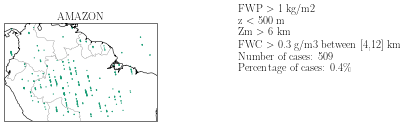

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 20),
                            subplot_kw={'projection': ccrs.PlateCarree()},
                                    constrained_layout=True)

ax1, ax2 = axes

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.3)

ax1.scatter(Longitude[filter_idxs], Latitude[filter_idxs], s=5)

ax1.set_title(f"{case.replace('_', ' ').upper()}")

ax2.axis("off")

info_string = f'FWP $>$ {filter_info["Fwp"]} kg/m2 \n z $<$ {filter_info["surface_altitude"]} m\n Zm $>$ {filter_info["Zm"]} km\n'
info_string += f'FWC $>$ {1000*filter_info["Fwc_threshold"]} g/m3 between [4,12] km \n'
info_string += f'Number of cases: {len(filter_idxs)} \n'
info_string += f'Percentage of cases: {round(100*len(filter_idxs)/len(filter_idxs_region),1)}\%'

ax2.text(x=1, y=1, s=info_string, fontsize=20);

plt.savefig(
    f"../figures/deep_convection/map_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")


/tmp/ipykernel_9362/3244730875.py:17: UserWarning: Log scale: values of z <= 0 have been masked
  cf1 = ax.contourf(Xf.T, Yf.T, H_fwc, levels=levels, norm=LogNorm(vmin=1e-3, vmax=1e1), cmap="Blues")
/tmp/ipykernel_9362/3244730875.py:37: UserWarning: Log scale: values of z <= 0 have been masked
  cf2 = ax2.contourf(Xd.T, Yd.T, H_dm, levels=levels, norm=LogNorm(vmin=1e-3, vmax=1e1), cmap="Blues")


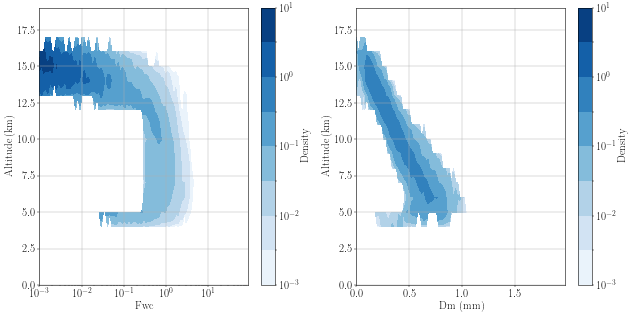

In [9]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(16,8))

levels = np.logspace(-3,1,9)

# --- Fwc 2D histogram ---
Fwc_flat = Fwc[filter_idxs].flatten()
alt_flat = np.tile(altitude, len(filter_idxs))

H_fwc, xedges_fwc, yedges_fwc = np.histogram2d(
    Fwc_flat*1000, alt_flat,
    bins=[Fwc_bins, altitude_bins],
    density=True
)

# pcolormesh expects (x, y) but H is (nx, ny), so transpose
Xf, Yf = np.meshgrid(xedges_fwc[:-1], yedges_fwc[:-1])
cf1 = ax.contourf(Xf.T, Yf.T, H_fwc, levels=levels, norm=LogNorm(vmin=1e-3, vmax=1e1), cmap="Blues")
plt.colorbar(cf1, ax=ax, label="Density")
ax.set_xscale("log")
##ax.axvline(1e-4, c="grey")
#ax.axhline(6)
#ax.axhline(12)
ax.set_xlabel("Fwc")
ax.set_ylabel("Altitude (km)")
ax.grid()

# --- Dm 2D histogram ---
Dm_flat = (ds.Fwc_Dm.values[filter_idxs] / 1e-3).flatten()

H_dm, xedges_dm, yedges_dm = np.histogram2d(
    Dm_flat, alt_flat,
    bins=[Dm_bins_mm, altitude_bins],
    density=True
)

Xd, Yd = np.meshgrid(xedges_dm[:-1], yedges_dm[:-1])
cf2 = ax2.contourf(Xd.T, Yd.T, H_dm, levels=levels, norm=LogNorm(vmin=1e-3, vmax=1e1), cmap="Blues")
plt.colorbar(cf2, ax=ax2, label="Density")
ax2.set_xlabel("Dm (mm)")
ax2.set_ylabel("Altitude (km)")
ax2.grid()

plt.tight_layout()


In [10]:
np.logspace(-3,1,9)

array([1.00000000e-03, 3.16227766e-03, 1.00000000e-02, 3.16227766e-02,
       1.00000000e-01, 3.16227766e-01, 1.00000000e+00, 3.16227766e+00,
       1.00000000e+01])

# Inclusion of FWC condition

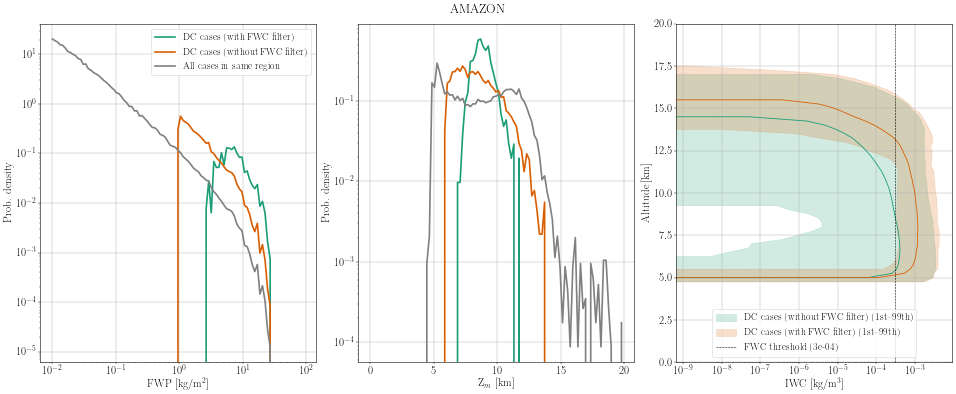

In [11]:
# DC mask without Fwc threshold for comparison
dc_mask_no_fwc = (
    region_mask &
    (Fwp    > filter_info["Fwp"]) &
    (Zm     > filter_info["Zm"]) &
    (Surf_z < filter_info["surface_altitude"])
)

fig, axes = plt.subplots(1, 3, figsize=(24, 10))

counts, _ = np.histogram(Fwp[dc_mask], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="C0", label="DC cases (with FWC filter)")
counts, _ = np.histogram(Fwp[dc_mask_no_fwc], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="C1", label="DC cases (without FWC filter)")
counts, _ = np.histogram(Fwp[region_mask], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="grey", label="All cases in same region")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("FWP [kg/m$^{2}$]")
axes[0].set_ylabel("Prob. density")

counts, _ = np.histogram(Zm[dc_mask], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="C0")
counts, _ = np.histogram(Zm[dc_mask_no_fwc], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="C1")
counts, _ = np.histogram(Zm[region_mask], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="grey")
axes[1].set_yscale("log")
axes[1].set_xlabel("Z$_{m}$ [km]")
axes[1].set_ylabel("Prob. density")

# IWC profiles
for mask, color, label in [
    (dc_mask_no_fwc, "C0",   "DC cases (without FWC filter)"),
    (dc_mask,        "C1",   "DC cases (with FWC filter)"),
]:
    profiles     = Fwc[mask, :]
    mean_profile = np.mean(profiles, axis=0)
    p01_profile  = np.percentile(profiles, 1,  axis=0)
    p50_profile  = np.percentile(profiles, 50,  axis=0)
    p99_profile  = np.percentile(profiles, 99, axis=0)

    axes[2].plot(p50_profile, altitude, c=color, lw=1.5)
    axes[2].fill_betweenx(altitude, p01_profile, p99_profile,
                          color=color, alpha=0.2, label=f"{label} (1st–99th)")

# Add vertical line showing Fwc threshold
axes[2].axvline(fwc_thresh, c="k", lw=1, ls="--", label=f"FWC threshold ({fwc_thresh:.0e})")

axes[2].set_xscale("log")
axes[2].set_xlabel("IWC [kg/m$^{3}$]")
axes[2].set_ylabel("Altitude [km]")
axes[2].set_ylim(0, 20)

for ax in axes:
    ax.grid()
axes[0].legend()
axes[2].legend(loc="lower center")

fig.suptitle(f"{case.upper()}", fontsize=24)
fig.tight_layout()

plt.savefig(
    f"../figures/deep_convection/inclusion_of_FWC_comparison_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")


# Spectra for chosen DC cases

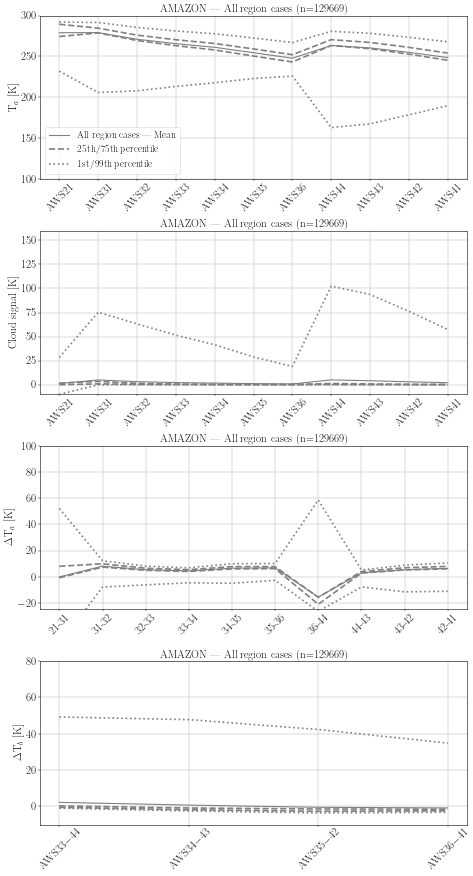

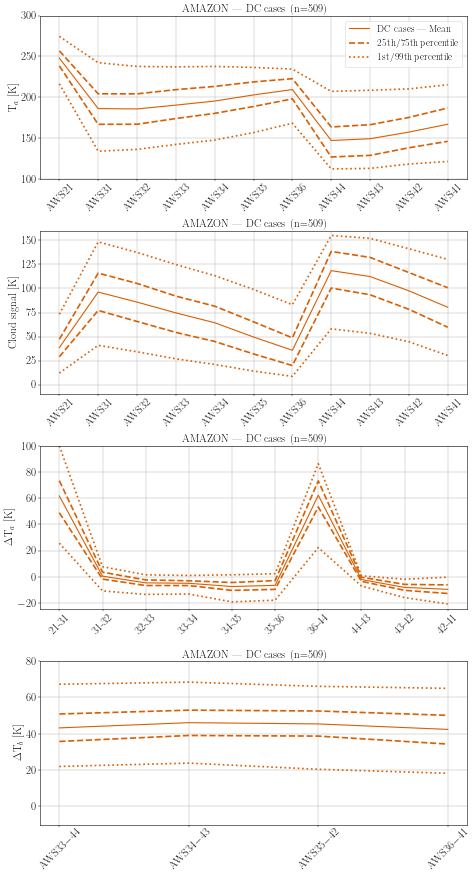

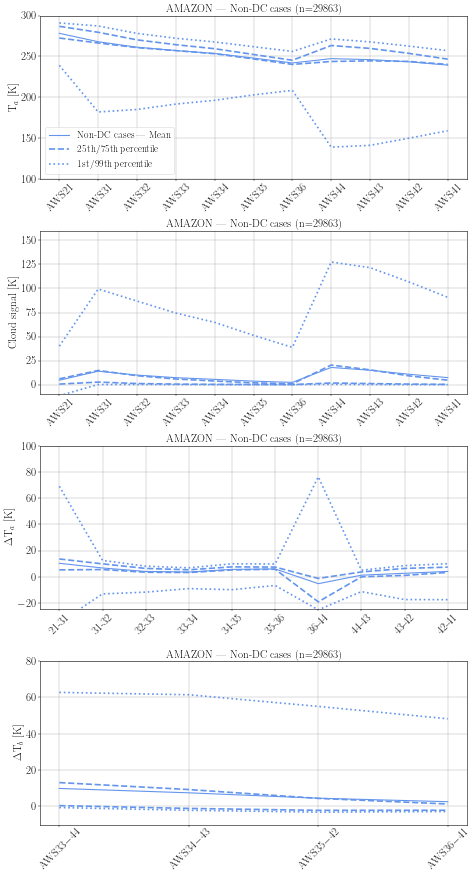

In [12]:
mask_configs = [
    {"mask": region_mask, "color": "grey",           "label": "All region cases",  "name": "region"},
    {"mask": dc_mask,     "color": "C1",              "label": "DC cases",          "name": "dc"},
    {"mask": no_dc_mask,  "color": "cornflowerblue",  "label": "Non-DC cases",      "name": "no_dc"},
]

for mcfg in mask_configs:
    idx   = np.where(mcfg["mask"])[0]
    color = mcfg["color"]
    label = mcfg["label"]

    dTb_data = np.stack([
        Ta(33)[idx] - Ta(44)[idx],
        Ta(34)[idx] - Ta(43)[idx],
        Ta(35)[idx] - Ta(42)[idx],
        Ta(36)[idx] - Ta(41)[idx],
    ], axis=1)

    plot_configs = [
        {
            "data":         Ta_array[idx],
            "x":            np.arange(11),
            "ylabel":       r"T$_{a}$ [K]",
            "xticklabels":  channels,
            "diff":         False,
            "ylim":         [100, 300],
        },
        {
            "data":         CS_array[idx],
            "x":            np.arange(11),
            "ylabel":       r"Cloud signal [K]",
            "xticklabels":  channels,
            "diff":         False,
            "ylim":         [-10, 160],
        },
        {
            "data":         Ta_array[idx],
            "x":            np.arange(10),
            "ylabel":       r"$\Delta$T$_{a}$ [K]",
            "xticklabels":  channels_diffs,
            "diff":         True,
            "ylim":         [-25, 100],
        },
        {
            "data":         dTb_data,
            "x":            np.arange(4),
            "ylabel":       r"$\Delta$T$_{b}$ [K]",
            "xticklabels":  ["AWS33−44", "AWS34−43", "AWS35−42", "AWS36−41"],
            "diff":         False,
            "ylim":         [-10, 80],
        },
    ]

    fig, axes = plt.subplots(4, 1, figsize=(12, 22))

    for i, (ax, cfg) in enumerate(zip(axes, plot_configs)):
        d = -1 * np.diff(cfg["data"]) if cfg["diff"] else cfg["data"]
        x = cfg["x"]

        ax.plot(x, np.mean(d, axis=0),                        c=color,  lw=2,      label=f"{label} — Mean")
        ax.plot(x, np.percentile(d, 25, axis=0), ls="--",     c=color,             label="25th/75th percentile")
        ax.plot(x, np.percentile(d, 75, axis=0), ls="--",     c=color)
        ax.plot(x, np.percentile(d,  1, axis=0), ls=":",      c=color,             label="1st/99th percentile")
        ax.plot(x, np.percentile(d, 99, axis=0), ls=":",      c=color)

        ax.set_xticks(x)
        ax.set_xticklabels(cfg["xticklabels"])
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel(cfg["ylabel"])
        ax.set_ylim(cfg["ylim"])
        ax.set_title(f"{case.replace('_', ' ').upper()} — {label} (n={len(idx)})")
        ax.grid()
        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"../figures/deep_convection/combined_spectrum_{case}_{mcfg['name']}.png",
        dpi=200, bbox_inches="tight", facecolor="white"
    )

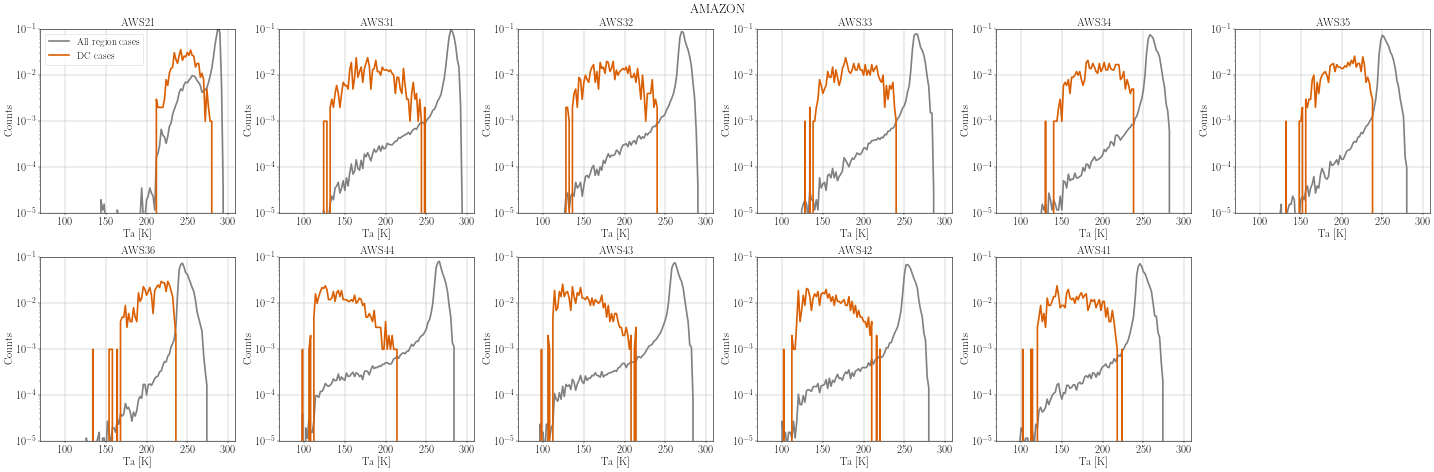

In [13]:
region_idxs = np.where(region_mask)[0]

fig, axes = plt.subplots(2, 6, figsize=(36, 12))
axes = axes.flatten()

for i, ch in enumerate(channels):
    counts, _ = np.histogram(Ta_array[region_idxs, i], bins=Ta_bins, density=True)
    axes[i].plot(Ta_bins[:-1], counts, c="grey", label="All region cases")
    counts, _ = np.histogram(Ta_array[filter_idxs, i], bins=Ta_bins, density=True)
    axes[i].plot(Ta_bins[:-1], counts, c="C1", label="DC cases")
    axes[i].set_yscale("log")
    axes[i].set_xlabel("Ta [K]")
    axes[i].set_ylabel("Counts")
    axes[i].set_title(ch)
    axes[i].grid()
    axes[i].set_ylim([1e-5, 1e-1])

axes[0].legend()
axes[-1].set_visible(False)
fig.suptitle(f"{case.upper()}", fontsize=24)
plt.tight_layout()

plt.savefig(
    f"../figures/deep_convection/Ta_distributions_{case}.png",
    dpi=200, bbox_inches="tight", facecolor="white"
)

In [14]:
100*np.sum(Ta(44)[filter_idxs] > 200) / np.sum(Ta(44)[filter_idxs] > 0)

np.float64(2.5540275049115913)

# Identifying DC with Ta

In [27]:
# ── Tropical masks ────────────────────────────────────────────────────────────
tropics_mask = (Latitude > -30) & (Latitude < 30)

Ta_3533 = (Ta(35) - Ta(33))
Ta_3534 = (Ta(35) - Ta(34))
Ta_3433 = (Ta(34) - Ta(33))

Ta_3332 = (Ta(33) - Ta(32))

Ta_4244 = (Ta(42) - Ta(44))
Ta_4243 = (Ta(42) - Ta(43))
Ta_4344 = (Ta(43) - Ta(44))

condition_dc = (
    tropics_mask &
    (Ta(32) < 240) &
    (Ta(33) < 240) &
    (Ta(34) < 240) &
    (Ta(35) < 240) &
    (Ta(36) < 240) &
    (Ta(41) < 220) &
    (Ta(42) < 220) &
    (Ta(43) < 220) &
    (Ta(44) < 220) &
    (Ta_3533 >= Ta_3534) & 
    (Ta_3534 >= Ta_3433) & 
    (Ta_3433 >= 0) &
    ( (np.abs(Ta(33) - Ta(34)) - np.abs(Ta(44) - Ta(43)) ) > 1)
)

# hong
# 32, 34, 36
# 36-32 >= 36-34 >= 34-32 >= 0

# hong for 4X
# 42-44 >= 42-43 >= 43-44 >= 0


tropics_dc_idxs          = np.where(condition_dc)[0]
all_tropics_idxs = np.where(tropics_mask)[0]

print(f"Total cases in tropics:  {len(all_tropics_idxs)}")
print(f"Total potential DC:      {len(tropics_dc_idxs)}")



Total cases in tropics:  2636260
Total potential DC:      6248


In [28]:
overlap_idxs = np.intersect1d(filter_idxs, tropics_dc_idxs)
non_overlap_idxs = np.setdiff1d(filter_idxs, tropics_dc_idxs)

print(f"{len(filter_idxs)} cases, {len(overlap_idxs)} shared with dc_idxs ({100*len(overlap_idxs)/len(filter_idxs):.1f}%)")
print(f"{len(non_overlap_idxs)} cases not in dc_idxs ({100*len(non_overlap_idxs)/len(filter_idxs):.1f}%)")

509 cases, 367 shared with dc_idxs (72.1%)
142 cases not in dc_idxs (27.9%)


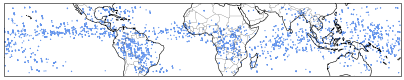

In [29]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 20),
                            subplot_kw={'projection': ccrs.PlateCarree()},
                                    constrained_layout=True)

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.3)

ax1.scatter(Longitude[tropics_dc_idxs], Latitude[tropics_dc_idxs], s=5, c="cornflowerblue")


plt.savefig(
    f"../figures/deep_convection/map_dc_condition.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")


/tmp/ipykernel_9362/1794820614.py:32: UserWarning: Log scale: values of z <= 0 have been masked
  cf = axes[2].contourf(X, Y, h1.T, levels=levels, norm=LogNorm(vmin=1e-3, vmax=1e1), cmap="copper_r")
/tmp/ipykernel_9362/1794820614.py:33: UserWarning: Log scale: values of z <= 0 have been masked
  axes[2].contour(X, Y, h2.T, levels=levels, norm=LogNorm(vmin=1e-3, vmax=1e1), colors="cornflowerblue", linewidths=2)


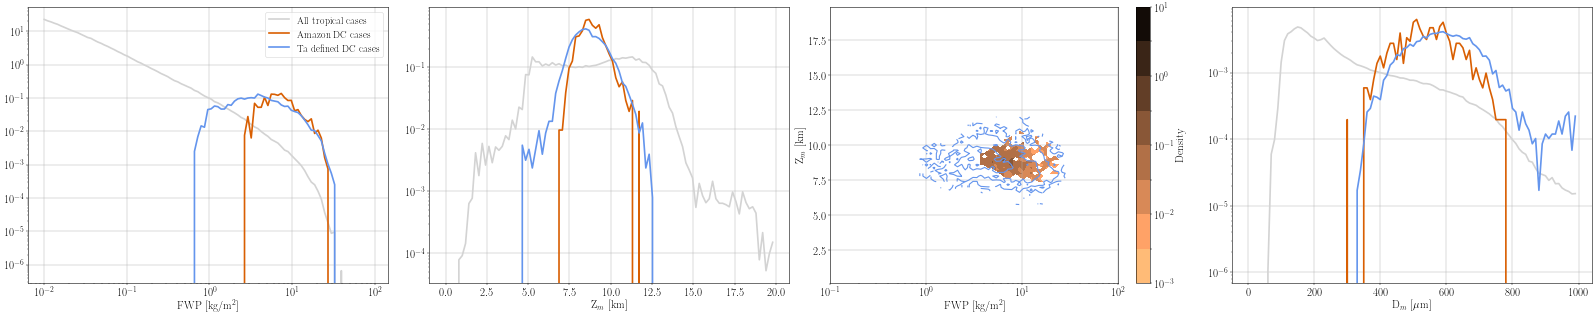

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(40, 8))

counts, _ = np.histogram(Fwp[all_tropics_idxs], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="lightgrey", label="All tropical cases")
counts, _ = np.histogram(Fwp[filter_idxs], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="C1", label="Amazon DC cases")
counts, _ = np.histogram(Fwp[tropics_dc_idxs], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="cornflowerblue", label="Ta defined DC cases")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("FWP [kg/m$^{2}$]")
axes[0].legend()

counts, _ = np.histogram(Zm[all_tropics_idxs], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="lightgrey")
counts, _ = np.histogram(Zm[filter_idxs], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="C1")
counts, _ = np.histogram(Zm[tropics_dc_idxs], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="cornflowerblue")
axes[1].set_yscale("log")
axes[1].set_xlabel("Z$_{m}$ [km]")

# 2D histogram of FWP vs Zm
levels = np.logspace(-3, 1, 9)
h1, xedges, yedges = np.histogram2d(Fwp[filter_idxs], Zm[filter_idxs],
                                     bins=[Fwp_bins, Zm_bins], density=True)
h2, _, _ = np.histogram2d(Fwp[tropics_dc_idxs], Zm[tropics_dc_idxs],
                           bins=[Fwp_bins, Zm_bins], density=True)
Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc)
cf = axes[2].contourf(X, Y, h1.T, levels=levels, norm=LogNorm(vmin=1e-3, vmax=1e1), cmap="copper_r")
axes[2].contour(X, Y, h2.T, levels=levels, norm=LogNorm(vmin=1e-3, vmax=1e1), colors="cornflowerblue", linewidths=2)
fig.colorbar(cf, ax=axes[2], label="Density")
axes[2].set_xlabel("FWP [kg/m$^{2}$]")
axes[2].set_ylabel("Z$_{m}$ [km]")
axes[2].set_xscale("log")
axes[2].set_xlim([1e-1, 1e2])

counts, _ = np.histogram(Dm[all_tropics_idxs], bins=Dm_bins, density=True)
axes[3].plot(Dm_bins[:-1], counts, c="lightgrey", label="All tropical cases")
counts, _ = np.histogram(Dm[filter_idxs], bins=Dm_bins, density=True)
axes[3].plot(Dm_bins[:-1], counts, c="C1", label="Amazon DC cases")
counts, _ = np.histogram(Dm[tropics_dc_idxs], bins=Dm_bins, density=True)
axes[3].plot(Dm_bins[:-1], counts, c="cornflowerblue", label="Ta defined DC cases")
axes[3].set_yscale("log")
axes[3].set_xlabel("D$_{m}$ [$\mu$m]")

for ax in axes:
    ax.grid()

plt.tight_layout()

plt.savefig(
    f"../figures/deep_convection/fwp_distributions_dc_condition_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")


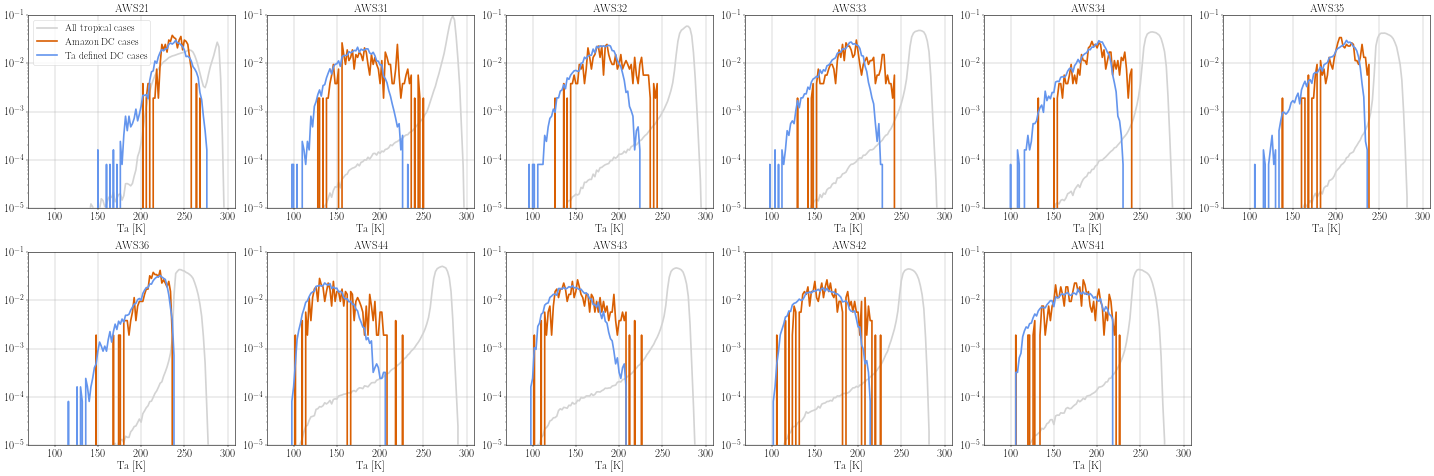

In [20]:
fig, axes = plt.subplots(2, 6, figsize=(36, 12))
axes = axes.flatten()

for i, ch in enumerate(channels):
    counts, _ = np.histogram(Ta_array[all_tropics_idxs, i], bins=Ta_bins, density=True)
    axes[i].plot(Ta_bins[:-1], counts, c="lightgrey", label="All tropical cases")
    counts, _ = np.histogram(Ta_array[filter_idxs, i], bins=Ta_bins, density=True)
    axes[i].plot(Ta_bins[:-1], counts, c="C1", label="Amazon DC cases")
    counts, _ = np.histogram(Ta_array[tropics_dc_idxs, i], bins=Ta_bins, density=True)
    axes[i].plot(Ta_bins[:-1], counts, c="cornflowerblue", label="Ta defined DC cases")
    axes[i].set_yscale("log")
    axes[i].set_xlabel("Ta [K]")
    axes[i].set_title(ch)
    axes[i].grid()
    axes[i].set_ylim([1e-5,1e-1])

axes[0].legend()

# Hide the unused last subplot
axes[-1].set_visible(False)

plt.tight_layout()

plt.savefig(
    f"../figures/deep_convection/ta_distributions_dc_condition_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")


/tmp/ipykernel_62889/1886015661.py:24: UserWarning: Log scale: values of z <= 0 have been masked
  cf = axes[i].contourf(X, Y, h2.T, levels=levels,


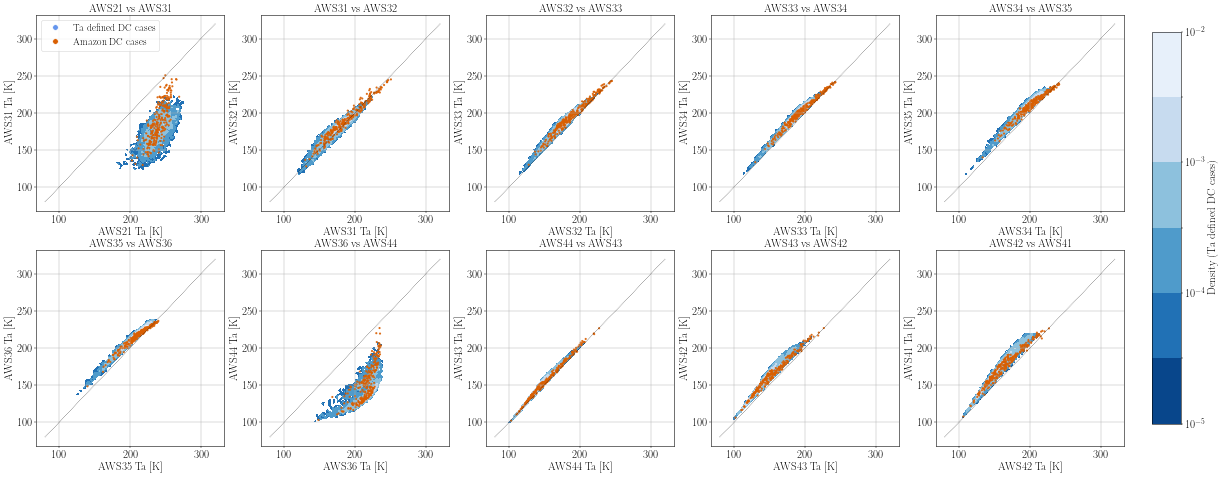

In [21]:
pairs = [(diff.split("-")[0], diff.split("-")[1]) for diff in channels_diffs]
ch_to_idx = {ch: i for i, ch in enumerate(channels)}

fig, axes = plt.subplots(2, 5, figsize=(36, 14))
plt.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
axes = axes.flatten()

levels = np.logspace(-5, -2, 7)

for i, (ch1, ch2) in enumerate(pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]

    h2, xedges, yedges = np.histogram2d(
        Ta_array[tropics_dc_idxs, idx1], Ta_array[tropics_dc_idxs, idx2],
        bins=[Ta_bins, Ta_bins], density=True
    )

    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)

    cf = axes[i].contourf(X, Y, h2.T, levels=levels,
                          norm=LogNorm(vmin=1e-5, vmax=1e-2), cmap="Blues_r")
    axes[i].scatter(Ta_array[filter_idxs, idx1], Ta_array[filter_idxs, idx2],
                    c="C1", s=15, alpha=0.9, label="Amazon DC cases")
    axes[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes[i].grid()

fig.colorbar(cf, cax=cax, label="Density (Ta defined DC cases)")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cornflowerblue',
           markersize=10, label='Ta defined DC cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C1',
           markersize=10, label='Amazon DC cases'),
]
axes[0].legend(handles=legend_elements, loc="upper left")

#plt.tight_layout()

plt.savefig(
    f"../figures/deep_convection/neighbour_distributions_dc_condition_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")


/tmp/ipykernel_62889/3440639743.py:24: UserWarning: Log scale: values of z <= 0 have been masked
  cf = axes[i].contourf(X, Y, h2.T, levels=levels,


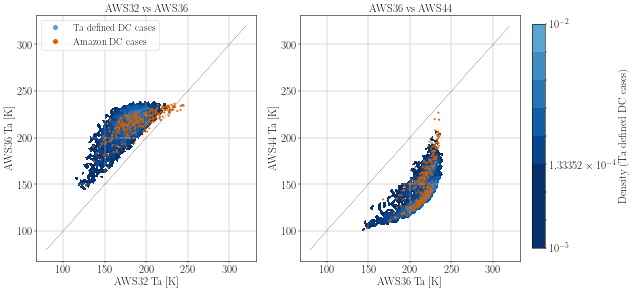

In [22]:
pairs = [("32", "36"), ("36", "44")]
ch_to_idx = {ch: i for i, ch in enumerate(channels)}

fig, axes = plt.subplots(1, 2, figsize=(16,8))
plt.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
axes = axes.flatten()

levels = np.logspace(-5, -2, 9)

for i, (ch1, ch2) in enumerate(pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]

    h2, xedges, yedges = np.histogram2d(
        Ta_array[tropics_dc_idxs, idx1], Ta_array[tropics_dc_idxs, idx2],
        bins=[Ta_bins, Ta_bins], density=True
    )

    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)

    cf = axes[i].contourf(X, Y, h2.T, levels=levels,
                          norm=LogNorm(vmin=1e-4, vmax=1e0), cmap="Blues_r")
    axes[i].scatter(Ta_array[filter_idxs, idx1], Ta_array[filter_idxs, idx2],
                    c="C1", s=15, alpha=0.9, label="Amazon DC cases")
    axes[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes[i].grid()

fig.colorbar(cf, cax=cax, label="Density (Ta defined DC cases)")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cornflowerblue',
           markersize=10, label='Ta defined DC cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C1',
           markersize=10, label='Amazon DC cases'),
]
axes[0].legend(handles=legend_elements, loc="upper left")

#plt.tight_layout()

/tmp/ipykernel_62889/1819226825.py:23: UserWarning: Log scale: values of z <= 0 have been masked
  cf = axes[0].contourf(X, Y, h2.T, levels=levels,


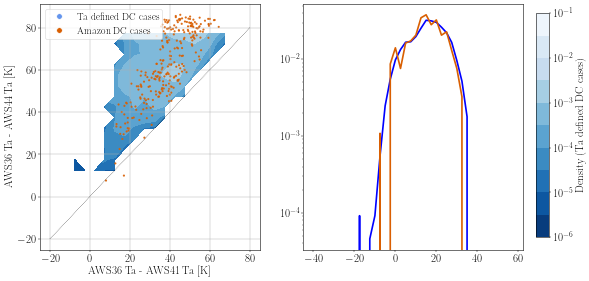

In [23]:
pairs = [("32", "36"), ("36", "44")]
ch_to_idx = {ch: i for i, ch in enumerate(channels)}

fig, axes = plt.subplots(1, 2, figsize=(16,8))
plt.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
axes = axes.flatten()

levels = np.logspace(-6, -1, 11)

array2 = Ta(36)[tropics_dc_idxs]-Ta(44)[tropics_dc_idxs]
array1 = Ta(36)[tropics_dc_idxs]-Ta(41)[tropics_dc_idxs]

h2, xedges, yedges = np.histogram2d(
    array1, array2,
    bins=[dTb_bins, dTb_bins], density=True
)

Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc)

cf = axes[0].contourf(X, Y, h2.T, levels=levels,
                      norm=LogNorm(vmin=1e-6, vmax=1e-1), cmap="Blues_r")

counts, _ = np.histogram(array1, bins=np.linspace(-40,100,41), density=True)
axes[1].plot(np.linspace(-40,60,41)[:-1], counts, c="blue")


#axes[0].scatter(array1, array2,
#                c="blue", s=15, alpha=0.9, label="Amazon DC cases")

array2 = Ta(36)[filter_idxs]-Ta(44)[filter_idxs]
array1 = Ta(36)[filter_idxs]-Ta(41)[filter_idxs]

axes[0].scatter(array1, array2,
                c="C1", s=15, alpha=0.9, label="Amazon DC cases")
axes[0].plot(dTb_bins, dTb_bins, c="k", lw=1, ls=":")
axes[0].set_ylabel(f"AWS36 Ta - AWS44 Ta [K]")
axes[0].set_xlabel(f"AWS36 Ta - AWS41 Ta [K]")
axes[0].grid()

fig.colorbar(cf, cax=cax, label="Density (Ta defined DC cases)")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cornflowerblue',
           markersize=10, label='Ta defined DC cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C1',
           markersize=10, label='Amazon DC cases'),
]
axes[0].legend(handles=legend_elements, loc="upper left")


counts, _ = np.histogram(array1, bins=np.linspace(-40,100,41), density=True)
axes[1].plot(np.linspace(-40,60,41)[:-1], counts, c="C1")

axes[1].set_yscale("log")

#plt.tight_layout()

# if a cloud is only low, then 44-33 stronger
# but 44 also scatters more - check hong

# if its a high cloud and now low, 33-44 less than 36-41

In [24]:
dTb_bins

array([-20., -15., -10.,  -5.,   0.,   5.,  10.,  15.,  20.,  25.,  30.,
        35.,  40.,  45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.])

/tmp/ipykernel_62889/1231257077.py:22: UserWarning: Log scale: values of z <= 0 have been masked
  cf = axes[i].contourf(X, Y, h2.T, levels=levels,


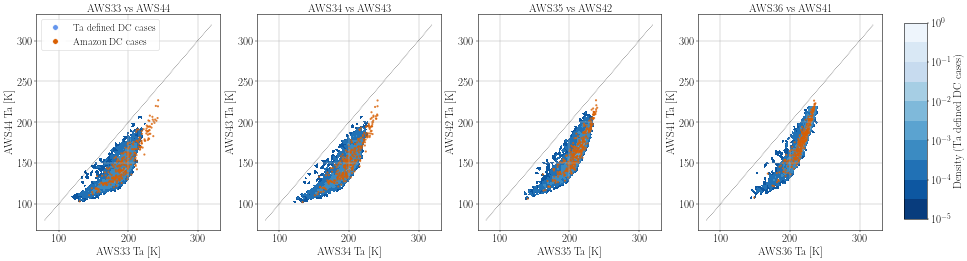

In [25]:
cross_pairs = [("33", "44"), ("34", "43"), ("35", "42"), ("36", "41")]

fig, axes = plt.subplots(1, 4, figsize=(28, 7))
plt.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])

levels = np.logspace(-5, 0, 11)

for i, (ch1, ch2) in enumerate(cross_pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]

    h2, xedges, yedges = np.histogram2d(
        Ta_array[tropics_dc_idxs, idx1], Ta_array[tropics_dc_idxs, idx2],
        bins=[Ta_bins, Ta_bins], density=True
    )

    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)

    cf = axes[i].contourf(X, Y, h2.T, levels=levels,
                          norm=LogNorm(vmin=1e-5, vmax=1e0), cmap="Blues_r")
    axes[i].scatter(Ta_array[filter_idxs, idx1], Ta_array[filter_idxs, idx2],
                    c="C1", s=15, alpha=0.8)
    axes[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes[i].grid()

fig.colorbar(cf, cax=cax, label="Density (Ta defined DC cases)")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cornflowerblue',
           markersize=10, label='Ta defined DC cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C1',
           markersize=10, label='Amazon DC cases'),
]
axes[0].legend(handles=legend_elements, loc="upper left")

plt.savefig(
    f"../figures/deep_convection/pair_distributions_dc_condition_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")


/tmp/ipykernel_62889/4070254972.py:36: UserWarning: Log scale: values of z <= 0 have been masked
  cf = axes[i].contourf(X, Y, h2.T, levels=levels,
/tmp/ipykernel_62889/4070254972.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


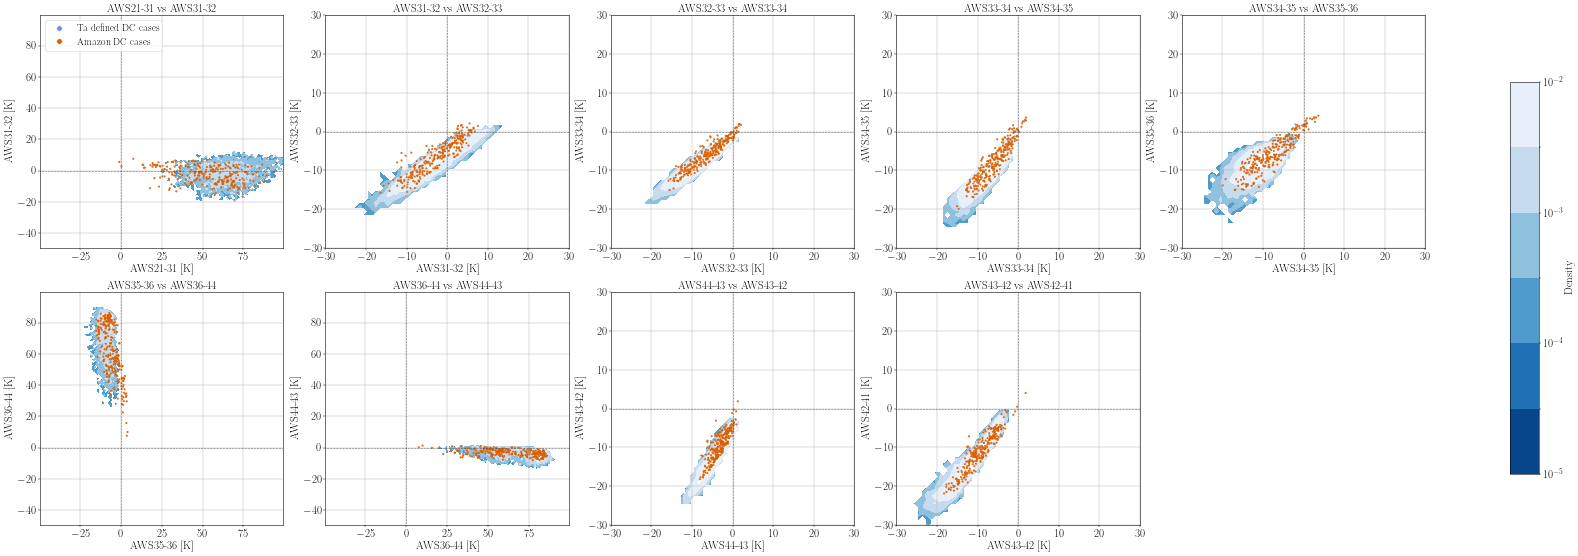

In [26]:
# Compute all difference arrays first
diff_arrays = {}
for diff in channels_diffs:
    ch1, ch2 = diff.split("-")
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]
    diff_arrays[diff] = Ta_array[:, idx1] - Ta_array[:, idx2]

# Consecutive pairs of differences
diff_pairs = [(channels_diffs[i], channels_diffs[i+1]) for i in range(len(channels_diffs)-1)]

fig, axes = plt.subplots(2, 5, figsize=(36, 14))
plt.subplots_adjust(right=0.85)  # push plots further left
cax = fig.add_axes([1.05, 0.15, 0.02, 0.7])  # move colorbar further right
axes = axes.flatten()
levels = np.logspace(-5, -2, 7)

for i, (diff1, diff2) in enumerate(diff_pairs):
    d1_tropic = diff_arrays[diff1][tropics_dc_idxs]
    d2_tropic = diff_arrays[diff2][tropics_dc_idxs]
    d1_filter = diff_arrays[diff1][filter_idxs]
    d2_filter = diff_arrays[diff2][filter_idxs]

    # Define bins based on data range
    all_vals = np.concatenate([d1_tropic, d2_tropic])
    bins = np.linspace(-50,100,151)

    h2, xedges, yedges = np.histogram2d(
        d1_tropic, d2_tropic,
        bins=[bins, bins], density=True
    )
    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)

    cf = axes[i].contourf(X, Y, h2.T, levels=levels,
                          norm=LogNorm(vmin=1e-5, vmax=1e-2), cmap="Blues_r")
    axes[i].scatter(d1_filter, d2_filter,
                    c="C1", s=15, alpha=0.9)
    axes[i].axhline(0, c="k", lw=1, ls=":")
    axes[i].axvline(0, c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{diff1} [K]")
    axes[i].set_ylabel(f"AWS{diff2} [K]")
    axes[i].set_title(f"AWS{diff1} vs AWS{diff2}")
    axes[i].grid()

    if i not in [0, 5, 6]:
        axes[i].set_xlim([-30, 30])
        axes[i].set_ylim([-30, 30])

fig.colorbar(cf, cax=cax, label="Density")
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cornflowerblue',
           markersize=10, label='Ta defined DC cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C1',
           markersize=10, label='Amazon DC cases'),
]
axes[0].legend(handles=legend_elements, loc="upper left")

fig.tight_layout()

axes[-1].set_visible(False)

plt.savefig(
    f"../figures/deep_convection/neighbour_diff_distributions_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

NameError: name 'symmetric_pairs' is not defined

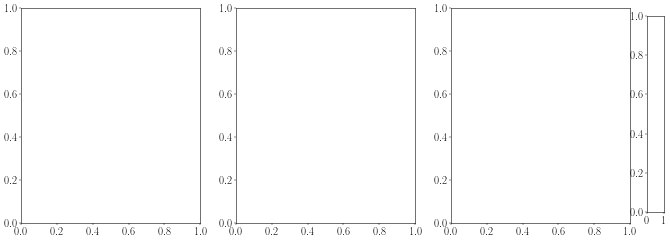

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
plt.subplots_adjust(right=0.85)
cax = fig.add_axes([0.87, 0.15, 0.02, 0.7])

levels = np.logspace(-5, -2, 7)

for i, (diff1, diff2) in enumerate(symmetric_pairs):
    d1_tropic = diff_arrays[diff1][tropics_dc_idxs]
    d2_tropic = diff_arrays[diff2][tropics_dc_idxs]
    d1_filter = diff_arrays[diff1][filter_idxs]
    d2_filter = diff_arrays[diff2][filter_idxs]

    bins = np.linspace(-50, 100, 151)
    h2, xedges, yedges = np.histogram2d(
        d1_tropic, d2_tropic,
        bins=[bins, bins], density=True
    )
    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)

    cf = axes[i].contourf(X, Y, h2.T, levels=levels,
                          norm=LogNorm(vmin=1e-5, vmax=1e-2), cmap="Blues_r")
    axes[i].scatter(d1_filter, d2_filter,
                    c="C1", s=15, alpha=0.9)
    axes[i].axhline(0, c="k", lw=1, ls=":")
    axes[i].axvline(0, c="k", lw=1, ls=":")
    axes[i].plot([-30, 30], [-30, 30], c="k", lw=1, ls="--")
    axes[i].set_xlabel(f"AWS{diff1} [K]")
    axes[i].set_ylabel(f"AWS{diff2} [K]")
    axes[i].set_title(f"AWS{diff1} vs AWS{diff2}")
    axes[i].set_xlim([-30, 30])
    axes[i].set_ylim([-30, 30])
    axes[i].grid()

fig.colorbar(cf, cax=cax, label="Density (tropics DC cases)")
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cornflowerblue',
           markersize=10, label='Ta defined DC cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C1',
           markersize=10, label='Amazon DC cases'),
]
axes[0].legend(handles=legend_elements, loc="upper left")
fig.tight_layout()
plt.savefig(
    f"../figures/deep_convection/symmetric_diff_contour_distributions_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

### Where are the low FWP cases coming from?

NameError: name 'bins' is not defined

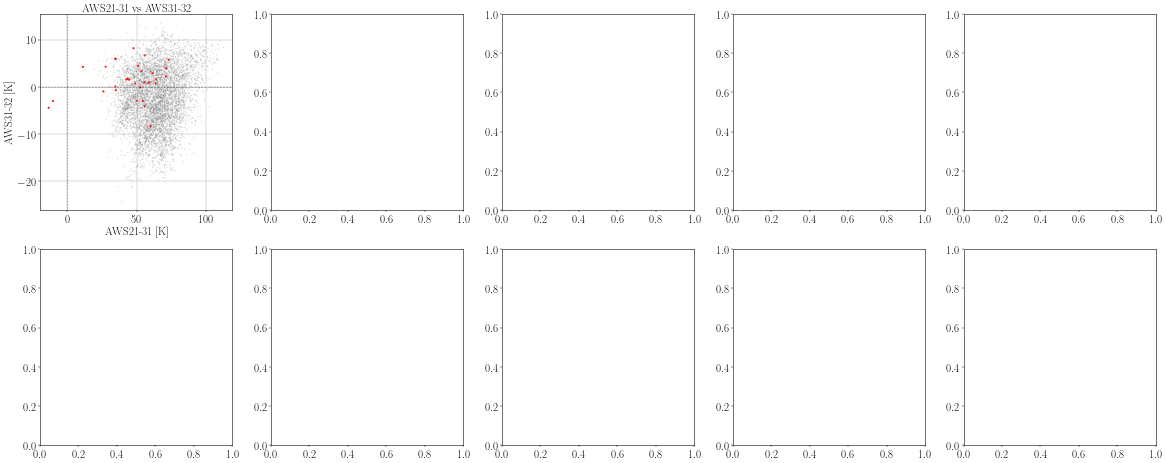

In [10]:
low_fwp_tropics  = tropics_dc_idxs[Fwp[tropics_dc_idxs] < 1]
high_fwp_tropics = tropics_dc_idxs[Fwp[tropics_dc_idxs] >= 1]


diff_arrays = {}
for diff in channels_diffs:
    ch1, ch2 = diff.split("-")
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]
    diff_arrays[diff] = Ta_array[:, idx1] - Ta_array[:, idx2]

diff_pairs = [(channels_diffs[i], channels_diffs[i+1]) for i in range(len(channels_diffs)-1)]

fig, axes = plt.subplots(2, 5, figsize=(36, 14))
axes = axes.flatten()

for i, (diff1, diff2) in enumerate(diff_pairs):
    d1_high = diff_arrays[diff1][high_fwp_tropics]
    d2_high = diff_arrays[diff2][high_fwp_tropics]
    d1_low  = diff_arrays[diff1][low_fwp_tropics]
    d2_low  = diff_arrays[diff2][low_fwp_tropics]

    axes[i].scatter(d1_high, d2_high, c="grey", s=5,  alpha=0.3)
    axes[i].scatter(d1_low,  d2_low,  c="red",  s=15, alpha=0.9)
    axes[i].axhline(0, c="k", lw=1, ls=":")
    axes[i].axvline(0, c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{diff1} [K]")
    axes[i].set_ylabel(f"AWS{diff2} [K]")
    axes[i].set_title(f"AWS{diff1} vs AWS{diff2}")
    axes[i].grid()
    if i not in [0, 5, 6]:
        axes[i].set_xlim([-30, 30])
        axes[i].set_ylim([-30, 30])

    axes[i].plot(bins, bins, ls="--", c="k", lw=1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=10, label=f'Tropical DC, FWP $\\geq$ 1 (n={len(high_fwp_tropics)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label=f'Tropical DC, FWP $<$ 1 (n={len(low_fwp_tropics)})'),
]
axes[0].legend(handles=legend_elements, loc="upper left")
axes[-1].set_visible(False)
fig.tight_layout()
plt.savefig(
    f"../figures/deep_convection/high_fwp_tropical_dc_dTb_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

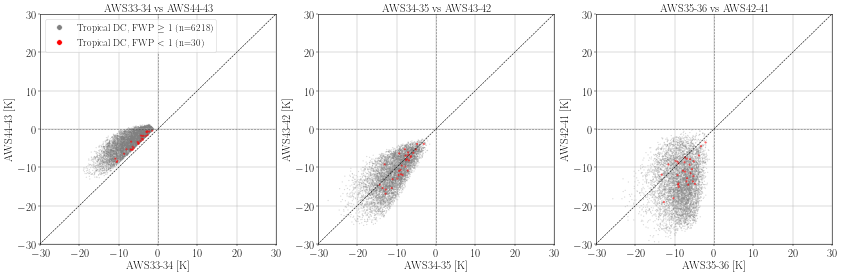

In [29]:
symmetric_pairs = [
    ("33-34", "44-43"),
    ("34-35", "43-42"),
    ("35-36", "42-41"),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for i, (diff1, diff2) in enumerate(symmetric_pairs):
    d1_high = diff_arrays[diff1][high_fwp_tropics]
    d2_high = diff_arrays[diff2][high_fwp_tropics]
    d1_low  = diff_arrays[diff1][low_fwp_tropics]
    d2_low  = diff_arrays[diff2][low_fwp_tropics]

    axes[i].scatter(d1_high, d2_high, c="grey", s=5,  alpha=0.3)
    axes[i].scatter(d1_low,  d2_low,  c="red",  s=15, alpha=0.6)
    axes[i].axhline(0, c="k", lw=1, ls=":")
    axes[i].axvline(0, c="k", lw=1, ls=":")
    axes[i].plot([-30, 30], [-30, 30], c="k", lw=1, ls="--")
    axes[i].set_xlabel(f"AWS{diff1} [K]")
    axes[i].set_ylabel(f"AWS{diff2} [K]")
    axes[i].set_title(f"AWS{diff1} vs AWS{diff2}")
    axes[i].set_xlim([-30, 30])
    axes[i].set_ylim([-30, 30])
    axes[i].grid()

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=10, label=f'Tropical DC, FWP $\\geq$ 1 (n={len(high_fwp_tropics)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label=f'Tropical DC, FWP $<$ 1 (n={len(low_fwp_tropics)})'),
]
axes[0].legend(handles=legend_elements, loc="upper left")
fig.tight_layout()
plt.savefig(
    f"../figures/deep_convection/high_fwp_tropical_dc_dTb_pairs_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

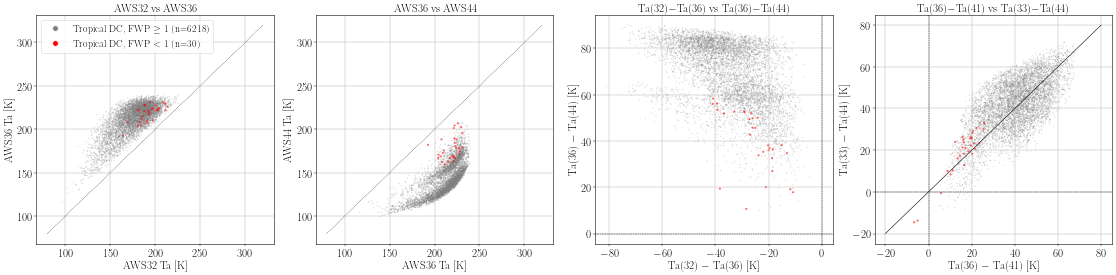

In [30]:
#low_fwp_tropics  = tropics_dc_idxs[Fwp[tropics_dc_idxs] < 1]
#high_fwp_tropics = tropics_dc_idxs[Fwp[tropics_dc_idxs] >= 1]

cross_pairs = [("32", "36"), ("36", "44")]
fig, axes = plt.subplots(1, 4, figsize=(28, 7))

for i, (ch1, ch2) in enumerate(cross_pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]
    axes[i].scatter(Ta_array[high_fwp_tropics, idx1], Ta_array[high_fwp_tropics, idx2],
                    c="grey", s=5, alpha=0.3)
    axes[i].scatter(Ta_array[low_fwp_tropics,  idx1], Ta_array[low_fwp_tropics,  idx2],
                    c="red", s=15, alpha=0.6)
    axes[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes[i].grid()

# Third subplot: Ta(32)-Ta(36) vs Ta(36)-Ta(44)
diff_32_36_high = Ta(32)[high_fwp_tropics] - Ta(36)[high_fwp_tropics]
diff_36_44_high = Ta(36)[high_fwp_tropics] - Ta(44)[high_fwp_tropics]
diff_32_36_low  = Ta(32)[low_fwp_tropics]  - Ta(36)[low_fwp_tropics]
diff_36_44_low  = Ta(36)[low_fwp_tropics]  - Ta(44)[low_fwp_tropics]

axes[2].scatter(diff_32_36_high, diff_36_44_high, c="grey", s=5,  alpha=0.3)
axes[2].scatter(diff_32_36_low,  diff_36_44_low,  c="red",  s=15, alpha=0.6)
axes[2].axhline(0, c="k", lw=0.8, ls="--")
axes[2].axvline(0, c="k", lw=0.8, ls="--")
axes[2].set_xlabel(r"Ta(32) $-$ Ta(36) [K]")
axes[2].set_ylabel(r"Ta(36) $-$ Ta(44) [K]")
axes[2].set_title("Ta(32)$-$Ta(36) vs Ta(36)$-$Ta(44)")
axes[2].grid()

# Fourth subplot: Ta(36)-Ta(41) vs Ta(33)-Ta(44)
diff_36_41_high = Ta(36)[high_fwp_tropics] - Ta(41)[high_fwp_tropics]
diff_33_44_high = Ta(33)[high_fwp_tropics] - Ta(44)[high_fwp_tropics]
diff_36_41_low  = Ta(36)[low_fwp_tropics]  - Ta(41)[low_fwp_tropics]
diff_33_44_low  = Ta(33)[low_fwp_tropics]  - Ta(44)[low_fwp_tropics]

axes[3].scatter(diff_36_41_high, diff_33_44_high, c="grey", s=5,  alpha=0.3)
axes[3].scatter(diff_36_41_low,  diff_33_44_low,  c="red",  s=15, alpha=0.6)
axes[3].axhline(0, c="k", lw=0.8, ls="--")
axes[3].axvline(0, c="k", lw=0.8, ls="--")
axes[3].set_xlabel(r"Ta(36) $-$ Ta(41) [K]")
axes[3].set_ylabel(r"Ta(33) $-$ Ta(44) [K]")
axes[3].set_title("Ta(36)$-$Ta(41) vs Ta(33)$-$Ta(44)")
axes[3].grid()
axes[3].plot(dTb_bins, dTb_bins, c="k", lw=1)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=10, label=f'Tropical DC, FWP $\\geq$ 1 (n={len(high_fwp_tropics)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label=f'Tropical DC, FWP $<$ 1 (n={len(low_fwp_tropics)})'),
]
axes[0].legend(handles=legend_elements, loc="upper left")
plt.tight_layout()

plt.savefig(
    f"../figures/deep_convection/high_fwp_tropical_dc_stuff_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

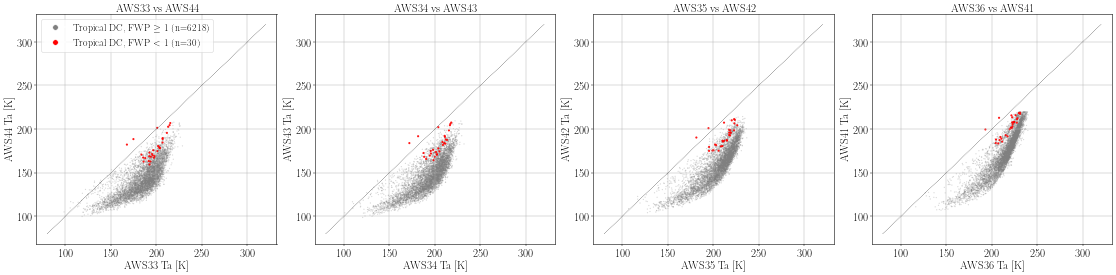

In [31]:
low_fwp_tropics  = tropics_dc_idxs[Fwp[tropics_dc_idxs] < 1]
high_fwp_tropics = tropics_dc_idxs[Fwp[tropics_dc_idxs] >= 1]

cross_pairs = [("33", "44"), ("34", "43"), ("35", "42"), ("36", "41")]
fig, axes = plt.subplots(1, 4, figsize=(28, 7))

for i, (ch1, ch2) in enumerate(cross_pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]

    axes[i].scatter(Ta_array[high_fwp_tropics, idx1], Ta_array[high_fwp_tropics, idx2],
                    c="grey", s=5, alpha=0.3)
    axes[i].scatter(Ta_array[low_fwp_tropics,  idx1], Ta_array[low_fwp_tropics,  idx2],
                    c="red",  s=15, alpha=0.9)
    axes[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes[i].grid()

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=10, label=f'Tropical DC, FWP $\\geq$ 1 (n={len(high_fwp_tropics)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label=f'Tropical DC, FWP $<$ 1 (n={len(low_fwp_tropics)})'),
]
axes[0].legend(handles=legend_elements, loc="upper left")
plt.tight_layout()

plt.savefig(
    f"../figures/deep_convection/high_fwp_tropical_dc_pairs_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

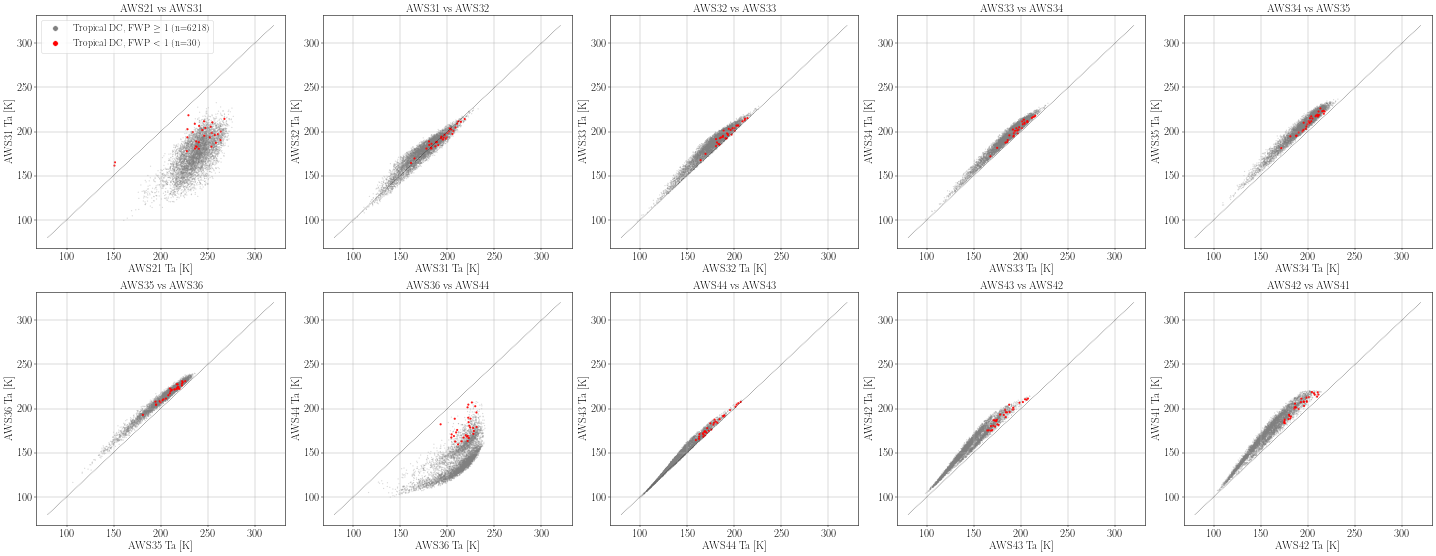

In [11]:
low_fwp_tropics  = tropics_dc_idxs[Fwp[tropics_dc_idxs] < 1]
high_fwp_tropics = tropics_dc_idxs[Fwp[tropics_dc_idxs] >= 1]

fig, axes = plt.subplots(2, 5, figsize=(36, 14))
plt.subplots_adjust(right=0.88)

pairs = [(diff.split("-")[0], diff.split("-")[1]) for diff in channels_diffs]
levels = np.logspace(-4, 1, 13)

for i, (ch1, ch2) in enumerate(pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]

    axes.flatten()[i].scatter(Ta_array[high_fwp_tropics, idx1], Ta_array[high_fwp_tropics, idx2],
                    c="grey", s=5, alpha=0.3)
    axes.flatten()[i].scatter(Ta_array[low_fwp_tropics,  idx1], Ta_array[low_fwp_tropics,  idx2],
                    c="red", s=15, alpha=0.9)
    axes.flatten()[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes.flatten()[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes.flatten()[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes.flatten()[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes.flatten()[i].grid()

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=10, label=f'Tropical DC, FWP $\\geq$ 1 (n={len(high_fwp_tropics)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label=f'Tropical DC, FWP $<$ 1 (n={len(low_fwp_tropics)})'),
]
axes.flatten()[0].legend(handles=legend_elements, loc="upper left")
plt.tight_layout()

plt.savefig(
    f"../figures/deep_convection/high_fwp_tropical_dc_Tb_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

In [ ]:
low_fwp_tropics  = tropics_dc_idxs[Fwp[tropics_dc_idxs] < 1]
high_fwp_tropics = tropics_dc_idxs[Fwp[tropics_dc_idxs] >= 1]

fig, axes = plt.subplots(1, 2, figsize=(24, 6))

for idxs, color, label in [
    #(high_fwp_tropics, "grey",           "Tropical DC, FWP $\\geq$ 1"),
    (low_fwp_tropics,  "cornflowerblue", "Tropical DC, FWP $<$ 1"),
    (filter_idxs,      "C1",             "Amazon DC cases"),
]:
    ta   = Ta_array[idxs]
    diff = -1 * np.diff(ta, axis=1)

    for ax, d, x, xlabels in [
        (axes[0], ta,   np.arange(len(channels)),       channels),
        (axes[1], diff, np.arange(len(channels_diffs)), channels_diffs),
    ]:
        ax.plot(x, np.mean(d, axis=0),                    c=color, lw=2, label=f"{label} — Mean")
        ax.plot(x, np.percentile(d, 25, axis=0), ls="--", c=color, lw=1, label=f"{label} — 25th/75th")
        ax.plot(x, np.percentile(d, 75, axis=0), ls="--", c=color, lw=1)
        ax.plot(x, np.percentile(d,  1, axis=0), ls=":",  c=color, lw=1, label=f"{label} — 1st/99th")
        ax.plot(x, np.percentile(d, 99, axis=0), ls=":",  c=color, lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, rotation=45)
        ax.grid()

axes[0].set_ylabel(r"T$_{a}$ [K]")
axes[0].set_ylim([100, 300])
axes[1].set_ylabel(r"$\Delta$T$_{a}$ [K]")
axes[1].set_ylim([-25, 20])
axes[1].axhline(0, c="k", lw=0.8, ls="--")

axes[1].grid()

axes[0].legend()
plt.tight_layout()

In [ ]:
low_fwp_tropics  = tropics_dc_idxs[Fwp[tropics_dc_idxs] < 1]
high_fwp_tropics = tropics_dc_idxs[Fwp[tropics_dc_idxs] >= 1]

fig, axes = plt.subplots(1, 2, figsize=(24, 6))

for idxs, color, label in [
    (high_fwp_tropics, "grey",           "Tropical DC, FWP $\\geq$ 1"),
    (low_fwp_tropics,  "cornflowerblue", "Tropical DC, FWP $<$ 1"),
]:
    ta   = Ta_array[idxs]
    diff = -1 * np.diff(ta, axis=1)

    for ax, d, x, xlabels in [
        (axes[0], ta,   np.arange(len(channels)),       channels),
        (axes[1], diff, np.arange(len(channels_diffs)), channels_diffs),
    ]:
        ax.plot(x, np.mean(d, axis=0),                    c=color, lw=2, label=f"{label} — Mean")
        ax.plot(x, np.percentile(d, 25, axis=0), ls="--", c=color, lw=1, label=f"{label} — 25th/75th")
        ax.plot(x, np.percentile(d, 75, axis=0), ls="--", c=color, lw=1)
        ax.plot(x, np.percentile(d,  1, axis=0), ls=":",  c=color, lw=1, label=f"{label} — 1st/99th")
        ax.plot(x, np.percentile(d, 99, axis=0), ls=":",  c=color, lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, rotation=45)
        ax.grid()

axes[0].set_ylabel(r"T$_{a}$ [K]")
axes[0].set_ylim([100, 300])
axes[1].set_ylabel(r"$\Delta$T$_{a}$ [K]")
axes[1].set_ylim([-25, 20])
axes[1].axhline(0, c="k", lw=0.8, ls="--")
axes[0].legend()
plt.tight_layout()

# Which Amazon cases might be problematic?

filter_idxs with Ta(31) > 220: 39


/tmp/ipykernel_62889/483300501.py:57: UserWarning: Adding colorbar to a different Figure <Figure size 1440x560 with 11 Axes> than <Figure size 960x320 with 4 Axes> which fig.colorbar is called on.
  fig.colorbar(cf, ax=axes[2], label="Density")


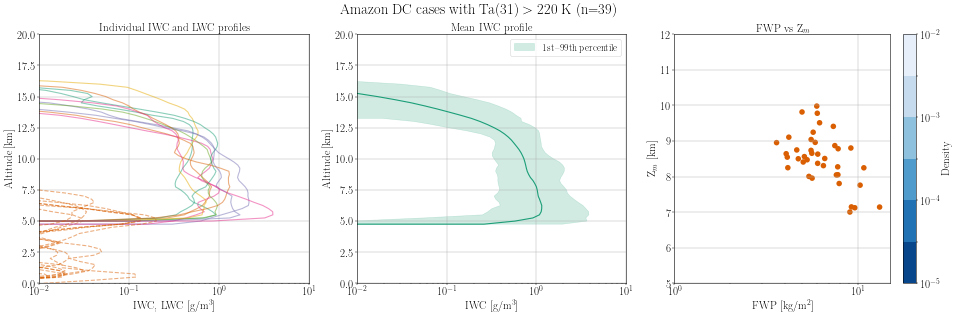

In [33]:
# ── Isolate filter_idxs with Ta(31) > 200 ────────────────────────────────────
idx31 = ch_to_idx["AWS31"]
high_ta31_idxs = filter_idxs[Ta_array[filter_idxs, idx31] > 220]
print(f"filter_idxs with Ta(31) > 220: {len(high_ta31_idxs)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Individual IWC profiles
for idx in high_ta31_idxs[0:10]:
    axes[0].plot(Fwc[idx, :]*1000, altitude,  alpha=0.5, lw=2)
    #axes[0].axvline(Fwp[idx])
    axes[0].plot(Lwc[idx, :]*1000, altitude, alpha=0.5, lw=2, c="C1", ls="--")
axes[0].set_xscale("log")
axes[0].set_xlabel("IWC, LWC [g/m$^{3}$]")
axes[0].set_ylabel("Altitude [km]")
axes[0].set_ylim(0, 20)
axes[0].set_xlim(1e-2, 1e1)
axes[0].set_title("Individual IWC and LWC profiles")
axes[0].grid()

# Mean IWC profile
axes[1].plot(np.mean(Fwc[high_ta31_idxs, :]*1000, axis=0), altitude, c="C0", lw=2)
axes[1].fill_betweenx(altitude,
    np.percentile(Fwc[high_ta31_idxs, :]*1000,  1, axis=0),
    np.percentile(Fwc[high_ta31_idxs, :]*1000, 99, axis=0),
    color="C0", alpha=0.2, label="1st–99th percentile")
axes[1].set_xlim(1e-2, 1e1)
axes[1].set_xscale("log")
axes[1].set_xlabel("IWC [g/m$^{3}$]")
axes[1].set_ylabel("Altitude [km]")
axes[1].set_ylim(0, 20)
axes[1].set_title("Mean IWC profile")
axes[1].legend()
axes[1].grid()

# FWP vs Zm contourf
#levels = np.logspace(-2, 0, 7)
#h, xedges, yedges = np.histogram2d(
#    Fwp[high_ta31_idxs], Zm[high_ta31_idxs],
#    bins=[Fwp_bins, Zm_bins], density=True
#)
axes[2].scatter(Fwp[high_ta31_idxs], Zm[high_ta31_idxs], c="C1")
#Xc = 0.5 * (xedges[:-1] + xedges[1:])
#Yc = 0.5 * (yedges[:-1] + yedges[1:])
#X, Y = np.meshgrid(Xc, Yc)
#cf = axes[2].contourf(X, Y, h.T, levels=levels,
#                      norm=LogNorm(vmin=1e-2, vmax=1e0), cmap="Blues")
axes[2].set_xscale("log")
axes[2].set_xlabel("FWP [kg/m$^{2}$]")
axes[2].set_ylabel("Z$_{m}$ [km]")
axes[2].set_title("FWP vs Z$_{m}$")
axes[2].grid()
axes[2].set_xlim([1, 15])
axes[2].set_ylim([5, 12])

fig.colorbar(cf, ax=axes[2], label="Density")

fig.suptitle(f"Amazon DC cases with Ta(31) $>$ 220 K (n={len(high_ta31_idxs)})", fontsize=26)
plt.tight_layout()

plt.tight_layout()
plt.savefig(
    f"../figures/deep_convection/iwc_distributions_overlap_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

In [34]:
( (np.abs(Ta(33) - Ta(34)) - np.abs(Ta(44) - Ta(43)) ) > 0)

array([ True,  True,  True, ...,  True,  True,  True])

/tmp/ipykernel_62889/1729921133.py:36: UserWarning: Adding colorbar to a different Figure <Figure size 1440x560 with 11 Axes> than <Figure size 1600x320 with 5 Axes> which fig.colorbar is called on.
  fig.colorbar(cf, ax=axes[2], label="Density")


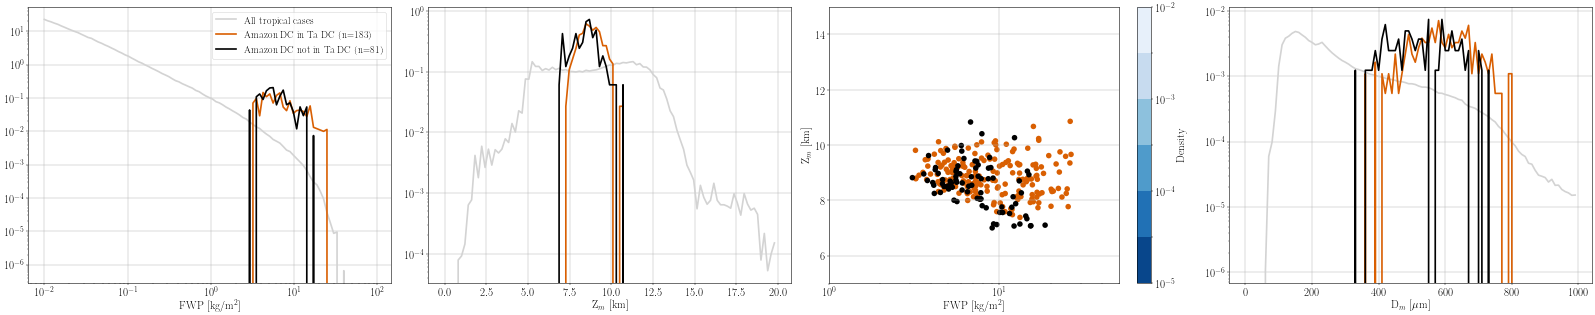

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(40, 8))

# FWP
counts, _ = np.histogram(Fwp[all_tropics_idxs], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="lightgrey", label="All tropical cases")
counts, _ = np.histogram(Fwp[overlap_idxs], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="C1", label=f"Amazon DC in Ta DC (n={len(overlap_idxs)})")
counts, _ = np.histogram(Fwp[non_overlap_idxs], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="k", label=f"Amazon DC not in Ta DC (n={len(non_overlap_idxs)})")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("FWP [kg/m$^{2}$]")
axes[0].legend()

# Zm
counts, _ = np.histogram(Zm[all_tropics_idxs], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="lightgrey")
counts, _ = np.histogram(Zm[overlap_idxs], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="C1")
counts, _ = np.histogram(Zm[non_overlap_idxs], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="k")
axes[1].set_yscale("log")
axes[1].set_xlabel("Z$_{m}$ [km]")

# 2D histogram FWP vs Zm
levels = np.logspace(-3, 1, 9)
h1, xedges, yedges = np.histogram2d(Fwp[overlap_idxs], Zm[overlap_idxs],
                                     bins=[Fwp_bins, Zm_bins], density=True)
h2, _, _ = np.histogram2d(Fwp[non_overlap_idxs], Zm[non_overlap_idxs],
                           bins=[Fwp_bins, Zm_bins], density=True)
Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc)
axes[2].scatter(Fwp[overlap_idxs], Zm[overlap_idxs], c="C1")
axes[2].scatter(Fwp[non_overlap_idxs], Zm[non_overlap_idxs], c="black")
fig.colorbar(cf, ax=axes[2], label="Density")
axes[2].set_xlabel("FWP [kg/m$^{2}$]")
axes[2].set_ylabel("Z$_{m}$ [km]")
axes[2].set_xscale("log")
axes[2].set_xlim([1, 50])
axes[2].set_ylim([5, 15])


# Dm
counts, _ = np.histogram(Dm[all_tropics_idxs], bins=Dm_bins, density=True)
axes[3].plot(Dm_bins[:-1], counts, c="lightgrey", label="All tropical cases")
counts, _ = np.histogram(Dm[overlap_idxs], bins=Dm_bins, density=True)
axes[3].plot(Dm_bins[:-1], counts, c="C1", label=f"Amazon DC in Ta DC (n={len(overlap_idxs)})")
counts, _ = np.histogram(Dm[non_overlap_idxs], bins=Dm_bins, density=True)
axes[3].plot(Dm_bins[:-1], counts, c="k", label=f"Amazon DC not in Ta DC (n={len(non_overlap_idxs)})")
axes[3].set_yscale("log")
axes[3].set_xlabel("D$_{m}$ [$\mu$m]")

for ax in axes:
    ax.grid()
plt.tight_layout()
plt.savefig(
    f"../figures/deep_convection/fwp_distributions_overlap_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

(100,)
(55,)
(55,)
(55,)
(55,)
(55,)
(55,)
(55,)
(55,)
(55,)
(55,)


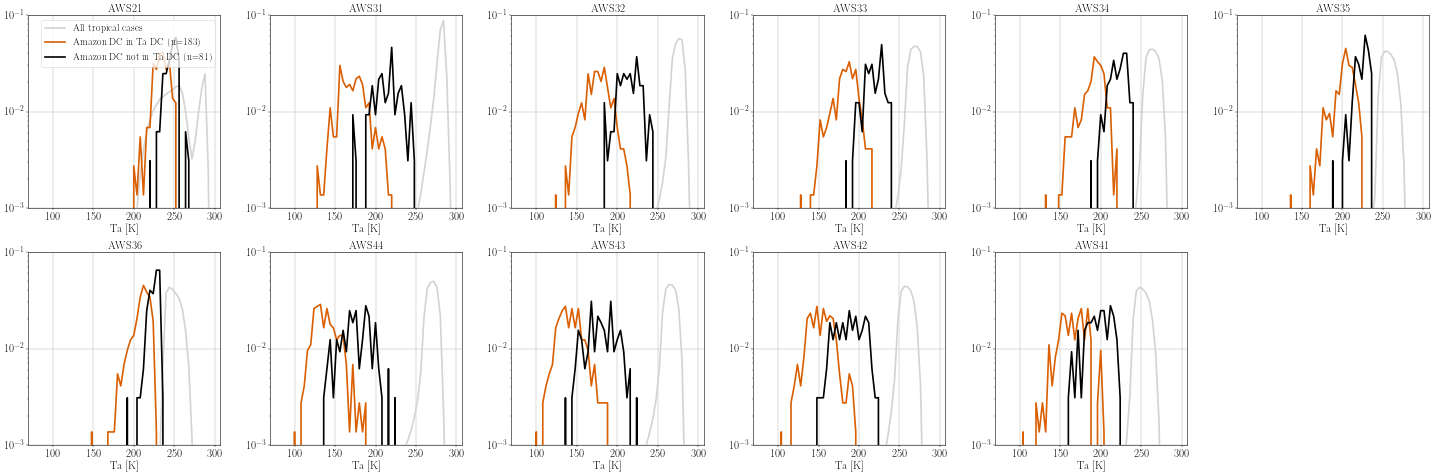

In [36]:


fig, axes = plt.subplots(2, 6, figsize=(36, 12))
axes = axes.flatten()
for i, ch in enumerate(channels):
    print(counts.shape)
    counts, _ = np.histogram(Ta_array[all_tropics_idxs, i], bins=Ta_bins_wider, density=True)
    axes[i].plot(Ta_bins_wider[:-1], counts, c="lightgrey", label="All tropical cases")
    counts, _ = np.histogram(Ta_array[overlap_idxs, i], bins=Ta_bins_wider, density=True)
    axes[i].plot(Ta_bins_wider[:-1], counts, c="C1", label=f"Amazon DC in Ta DC (n={len(overlap_idxs)})")
    counts, _ = np.histogram(Ta_array[non_overlap_idxs, i], bins=Ta_bins_wider, density=True)
    axes[i].plot(Ta_bins_wider[:-1], counts, c="k", label=f"Amazon DC not in Ta DC (n={len(non_overlap_idxs)})")
    axes[i].set_yscale("log")
    axes[i].set_xlabel("Ta [K]")
    axes[i].set_title(ch)
    axes[i].grid()
    axes[i].set_ylim([1e-3, 1e-1])
axes[0].legend()
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(
    f"../figures/deep_convection/ta_distributions_overlap_{case}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

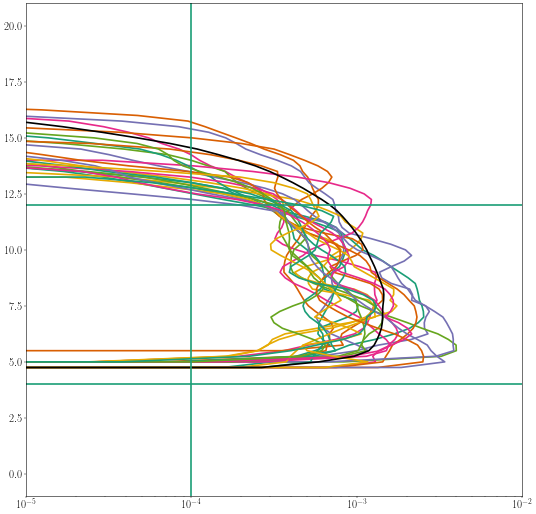

In [37]:
idxs_tmp = np.where(Ta_array[filter_idxs, 7] > 190)[0]

fig, ax = plt.subplots()

for i, idx in enumerate(idxs_tmp):
    ax.plot(Fwc[filter_idxs][idx], altitude)

ax.plot(np.mean(Fwc[filter_idxs], axis=0), altitude, c="k")
    
ax.set_xscale("log")

ax.set_xlim([1e-5, 1e-2])

ax.axvline(1e-4)
ax.axhline(4)
ax.axhline(12)

In [38]:
idx33 = ch_to_idx["AWS33"]
idx44 = ch_to_idx["AWS44"]
filter_above200_idxs = filter_idxs[
    (Ta_array[filter_idxs, idx33] > 200) &
    (Ta_array[filter_idxs, idx44] > 200)
]

low_fwp_dc_idxs = dc_idxs[Fwp[dc_idxs] < 1]
cross_pairs = [("33", "44"), ("34", "43"), ("35", "42"), ("36", "41")]
fig, axes = plt.subplots(1, 4, figsize=(28, 7))
plt.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
levels = np.logspace(-5, 1, 13)
for i, (ch1, ch2) in enumerate(cross_pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]
    h2, xedges, yedges = np.histogram2d(
        Ta_array[dc_idxs, idx1], Ta_array[dc_idxs, idx2],
        bins=[Ta_bins, Ta_bins], density=True
    )
    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)
    cf = axes[i].contourf(X, Y, h2.T, levels=levels,
                          norm=LogNorm(vmin=1e-5, vmax=1e1), cmap="copper_r")
    axes[i].scatter(Ta_array[filter_idxs, idx1], Ta_array[filter_idxs, idx2],
                    c="black", s=5, alpha=0.3)
    axes[i].scatter(Ta_array[low_fwp_dc_idxs, idx1], Ta_array[low_fwp_dc_idxs, idx2],
                    c="red", s=5, alpha=0.3)
    axes[i].scatter(Ta_array[filter_above200_idxs, idx1], Ta_array[filter_above200_idxs, idx2],
                    c="blue", s=20, alpha=0.3)
    axes[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes[i].grid()
fig.colorbar(cf, cax=cax, label="Density (Ta defined DC cases)")
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
           markersize=10, label='Ta defined DC cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
           markersize=10, label='Amazon DC cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label='Low FWP dc_idxs (FWP < 1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markersize=10, label='Amazon DC: AWS33 + AWS44 > 180K'),
]
axes[0].legend(handles=legend_elements, loc="upper left")
plt.tight_layout()

NameError: name 'dc_idxs' is not defined

In [ ]:
iwc_threshold = 1e-3  # kg/m³ - adjust as needed

def get_cloud_metrics(profiles, altitude, threshold):
    cloud_mask = profiles > threshold  # shape (n_profiles, n_altitudes)
    
    # Number of levels with ice
    n_levels = np.sum(cloud_mask, axis=1)
    
    # Cloud top and base (set to nan if no ice found)
    has_cloud = n_levels > 0
    
    cloud_top  = np.full(profiles.shape[0], np.nan)
    cloud_base = np.full(profiles.shape[0], np.nan)
    
    cloud_top[has_cloud]  = np.array([altitude[mask].max() for mask in cloud_mask[has_cloud]])
    cloud_base[has_cloud] = np.array([altitude[mask].min() for mask in cloud_mask[has_cloud]])
    cloud_depth = cloud_top - cloud_base

    return n_levels, cloud_top, cloud_base, cloud_depth

subsets = {
    "All tropical cases":           all_tropics_idxs,
    "Amazon DC cases":              filter_idxs,
    "Ta defined DC cases":          dc_idxs,
    "Low FWP dc_idxs (FWP < 1)":   low_fwp_dc_idxs,
    "Amazon DC AWS33+AWS44 > 200K": filter_above200_idxs,
}
colors = ["lightgrey", "C0", "C1", "red", "C0"]
linestyles = ["-", "-", "-", "-", "--"]

height_bins = np.linspace(0, 20, 81)
depth_bins  = np.linspace(0, 20, 81)
level_bins  = np.arange(0, 82, 1)

fig, axes = plt.subplots(1, 4, figsize=(32, 7))

for (label, idxs), color, ls in zip(subsets.items(), colors, linestyles):
    n_levels, cloud_top, cloud_base, cloud_depth = get_cloud_metrics(
        Fwc[idxs, :], altitude, iwc_threshold
    )

    # Only use profiles that have at least some ice
    valid = ~np.isnan(cloud_top)

    counts, _ = np.histogram(cloud_top[valid],   bins=height_bins, density=True)
    axes[0].plot(height_bins[:-1], counts, c=color, ls=ls, label=label)

    counts, _ = np.histogram(cloud_base[valid],  bins=height_bins, density=True)
    axes[1].plot(height_bins[:-1], counts, c=color, ls=ls, label=label)

    counts, _ = np.histogram(cloud_depth[valid], bins=depth_bins,  density=True)
    axes[2].plot(depth_bins[:-1],  counts, c=color, ls=ls, label=label)

    counts, _ = np.histogram(n_levels,           bins=level_bins,  density=True)
    axes[3].plot(level_bins[:-1],  counts, c=color, ls=ls, label=label)

axes[0].set_xlabel("Cloud top height [km]")
axes[1].set_xlabel("Cloud base height [km]")
axes[2].set_xlabel("Cloud depth [km]")
axes[3].set_xlabel("Number of levels with IWC > threshold")

for ax in axes:
    ax.set_ylabel("Density")
    ax.set_yscale("log")
    ax.grid()

axes[0].legend()

fig.suptitle(f"Cloud metrics (IWC threshold = {iwc_threshold} kg/m³)", y=1.02)
plt.tight_layout()

In [ ]:
def get_contiguous_layers(profiles, altitude, threshold):
    """
    For each profile, identify contiguous cloud layers.
    Returns cloud top, base, depth for single-layer clouds only (nan if multi-layer or no cloud).
    """
    n_profiles = profiles.shape[0]
    cloud_top   = np.full(n_profiles, np.nan)
    cloud_base  = np.full(n_profiles, np.nan)
    cloud_depth = np.full(n_profiles, np.nan)
    n_layers    = np.zeros(n_profiles, dtype=int)

    cloud_mask = profiles > threshold  # (n_profiles, n_altitudes)

    for i in range(n_profiles):
        mask = cloud_mask[i, :]
        if not np.any(mask):
            continue

        # Find contiguous layers by looking for transitions
        # diff will be 1 at layer start, -1 at layer end
        transitions = np.diff(mask.astype(int))
        layer_starts = np.where(transitions == 1)[0] + 1
        layer_ends   = np.where(transitions == -1)[0]

        # Handle edge cases where cloud starts at bottom or top
        if mask[0]:
            layer_starts = np.concatenate([[0], layer_starts])
        if mask[-1]:
            layer_ends = np.concatenate([layer_ends, [len(mask) - 1]])

        n_layers[i] = len(layer_starts)

        # Only keep single layer clouds
        if n_layers[i] == 1:
            cloud_base[i] = altitude[layer_starts[0]]
            cloud_top[i]  = altitude[layer_ends[0]]
            cloud_depth[i] = cloud_top[i] - cloud_base[i]

    return cloud_top, cloud_base, cloud_depth, n_layers


iwc_threshold = 1e-6

subsets = {
    "All tropical cases":           all_tropics_idxs,
    "Amazon DC cases":              filter_idxs,
    "Ta defined DC cases":          dc_idxs,
    "Low FWP dc_idxs (FWP < 1)":   low_fwp_dc_idxs,
}
colors     = ["lightgrey", "C0", "C1", "red"]
linestyles = ["-", "-", "-", "-"]

height_bins = np.linspace(0, 20, 81)
depth_bins  = np.linspace(0, 20, 81)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for (label, idxs), color, ls in zip(subsets.items(), colors, linestyles):
    cloud_top, cloud_base, cloud_depth, n_layers = get_contiguous_layers(
        Fwc[idxs, :], altitude, iwc_threshold
    )

    # Only single layer clouds
    single_layer = ~np.isnan(cloud_top)
    n_total  = len(idxs)
    n_single = np.sum(single_layer)

    counts, _ = np.histogram(cloud_top[single_layer],   bins=height_bins, density=True)
    axes[0].plot(height_bins[:-1], counts, c=color, ls=ls, label=f"{label} (n={n_single}/{n_total})")

    counts, _ = np.histogram(cloud_base[single_layer],  bins=height_bins, density=True)
    axes[1].plot(height_bins[:-1], counts, c=color, ls=ls, label=f"{label} (n={n_single}/{n_total})")

    counts, _ = np.histogram(cloud_depth[single_layer], bins=depth_bins,  density=True)
    axes[2].plot(depth_bins[:-1],  counts, c=color, ls=ls, label=f"{label} (n={n_single}/{n_total})")

axes[0].set_xlabel("Cloud top height [km]")
axes[1].set_xlabel("Cloud base height [km]")
axes[2].set_xlabel("Cloud depth [km]")

for ax in axes:
    ax.set_ylabel("Density")
    ax.set_yscale("log")
    ax.grid()
    ax.legend()

fig.suptitle(f"Single layer cloud metrics (IWC threshold = {iwc_threshold} kg/m³)", y=1.02)
plt.tight_layout()

In [ ]:
idx33 = ch_to_idx["AWS33"]
idx44 = ch_to_idx["AWS44"]


fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# FWP
counts, _ = np.histogram(Fwp[filter_idxs], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="C0", label="All Amazon DC cases")
counts, _ = np.histogram(Fwp[filter_above200_idxs], bins=Fwp_bins, density=True)
axes[0].plot(Fwp_bins[:-1], counts, c="red", ls="--", label="Amazon DC: AWS33, AWS44 > 200K")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("FWP [kg/m$^{2}$]")
axes[0].legend()
axes[0].grid()

# Zm
counts, _ = np.histogram(Zm[filter_idxs], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="C0", label="All Amazon DC cases")
counts, _ = np.histogram(Zm[filter_above200_idxs], bins=Zm_bins, density=True)
axes[1].plot(Zm_bins[:-1], counts, c="red", ls="--", label="Amazon DC: AWS33, AWS44 > 200K")
axes[1].set_yscale("log")
axes[1].set_xlabel("Z$_{m}$ [km]")
axes[1].grid()

# Dm
counts, _ = np.histogram(Dm[filter_idxs], bins=Dm_bins, density=True)
axes[2].plot(Dm_bins[:-1], counts, c="C0", label="All Amazon DC cases")
counts, _ = np.histogram(Dm[filter_above200_idxs], bins=Dm_bins, density=True)
axes[2].plot(Dm_bins[:-1], counts, c="red", ls="--", label="Amazon DC: AWS33, AWS44 > 200K")
axes[2].set_yscale("log")
axes[2].set_xlabel("D$_{m}$ [mm]")
axes[2].grid()

for ax in axes:
    ax.legend()

print(f"Total Amazon DC cases: {len(filter_idxs)}")
print(f"Amazon DC cases with AWS33 & AWS44 > 200K: {len(filter_above200_idxs)}")


In [ ]:
cross_pairs = [("33", "44"), ("34", "43"), ("35", "42"), ("36", "41")]
fig, axes = plt.subplots(1, 4, figsize=(30, 7))
plt.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])

levels = np.logspace(-6, 1, 13)
for i, (ch1, ch2) in enumerate(cross_pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]
    h1, xedges, yedges = np.histogram2d(
        Ta_array[all_tropics_idxs, idx1], Ta_array[all_tropics_idxs, idx2],
        bins=[Ta_bins, Ta_bins], density=True
    )
    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)
    cf = axes[i].contourf(X, Y, h1.T, levels=levels,
                          norm=LogNorm(vmin=1e-6, vmax=1e1), cmap="copper_r")
    sc = axes[i].scatter(Ta_array[filter_idxs, idx1], Ta_array[filter_idxs, idx2],
                    c="C0", s=10, alpha=0.3, label="Amazon DC")
    axes[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes[i].grid()

fig.colorbar(cf, cax=cax, label="Density (all tropical cases)")

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
           markersize=10, label='All tropical cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C0',
           markersize=10, label='Amazon DC cases'),
]
axes[0].legend(handles=legend_elements, loc="upper left")

In [ ]:
cross_pairs = [("33", "44"), ("34", "43"), ("35", "42"), ("36", "41")]
fig, axes = plt.subplots(1, 4, figsize=(30, 7))
plt.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])

levels = np.logspace(-6, 1, 13)
for i, (ch1, ch2) in enumerate(cross_pairs):
    idx1 = ch_to_idx[f"AWS{ch1}"]
    idx2 = ch_to_idx[f"AWS{ch2}"]
    h1, xedges, yedges = np.histogram2d(
        Ta_array[all_tropics_idxs, idx1], Ta_array[all_tropics_idxs, idx2],
        bins=[Ta_bins, Ta_bins], density=True
    )
    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)
    cf = axes[i].contourf(X, Y, h1.T, levels=levels,
                          norm=LogNorm(vmin=1e-6, vmax=1e1), cmap="copper_r")
    sc = axes[i].scatter(Ta_array[dc_idxs, idx1], Ta_array[dc_idxs, idx2],
                    c="blue", s=10, alpha=0.3, label="Amazon DC")
    axes[i].plot([80, 320], [80, 320], c="k", lw=1, ls=":")
    axes[i].set_xlabel(f"AWS{ch1} Ta [K]")
    axes[i].set_ylabel(f"AWS{ch2} Ta [K]")
    axes[i].set_title(f"AWS{ch1} vs AWS{ch2}")
    axes[i].grid()

fig.colorbar(cf, cax=cax, label="Density (all tropical cases)")

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
           markersize=10, label='All tropical cases'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markersize=10, label='DC cases'),
]
axes[0].legend(handles=legend_elements, loc="upper left")

In [ ]:
# where are turnover?

turnover_idxs = np.where((dtB_33_44 < 0) & (ds[f"Ta_Allsky_AWS33"].values < 150) & (np.abs(Latitude) < 30))[0]

In [ ]:
turnover_idxs.shape

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 20),
                            subplot_kw={'projection': ccrs.PlateCarree()},
                                    constrained_layout=True)

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.3)

ax1.scatter(Longitude[turnover_idxs], Latitude[turnover_idxs], s=15)


In [ ]:
print(Fwp[turnover_idxs])

In [ ]:
print(Zm[turnover_idxs])

In [ ]:
idxs_tmp = filter_idxs_no_dc[dtB_36_44[filter_idxs_no_dc] > 0]

In [ ]:
np.argmax(Fwp[idxs_tmp])

In [ ]:
Zm[idxs_tmp][2011]

In [ ]:
idxs_tmp2 = filter_idxs[dtB_36_44[filter_idxs] < 0]

In [ ]:
Fwp[idxs_tmp2]